<img src="logos/Logo_de_la_Facultad_Experimental_de_Ciencia_y_Tecnología.svg.png"
     width="250"
     style="display: block; margin-left: auto; margin-right: auto;">

# Exploratory Data Analysis: Premier League

## Purpose

This notebook presents a teaching example of **exploratory data analysis (EDA)**. Its goal is to understand the dataset's structure, quality, and patterns before building a model to predict the result of a football match.

EDA is not intended to prove causality or make final modeling decisions. It aims to:

- detect data quality issues;
- describe distributions and relationships;
- formulate hypotheses;
- acknowledge uncertainty and limitations;
- propose decisions that must later be validated.

**Unit of observation:** Un partido de futbol de la liga inglesa  
**Target variable:** `FTR` Full Time Result (`H`=Home Win, `D`=Draw, `A`=Away Win)  
**Downstream problem type:** Clasificacion Multiclase.


## Guiding questions

1. Which variables and data types does the dataset contain?
2. Are there duplicates, missing values, or suspicious values?
3. How is the target variable distributed?
4. How is the result associated with home/away, season, half-time result, and team strength?
5. Are there relevant interactions between variables?
6. What useful information can be extracted from the bookmaker odds?
7. Which preprocessing hypotheses should be validated during modeling?

> The observed associations describe this sample. By themselves, they do not imply causal relationships.


In [789]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RANDOM_STATE = 42

# Allow execution from either the project root or the notebooks/ directory.
PROJECT_ROOT = Path.cwd()
print(PROJECT_ROOT)
if not (PROJECT_ROOT  / "data" / "processed" / "premier_league_2021_2026.csv" ).exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "premier_league_2021_2026.csv"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_PATH.exists(), f"Dataset not found at {DATA_PATH}"

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.float_format", "{:.3f}".format)
plt.style.use("seaborn-v0_8-whitegrid")


c:\Users\user\Documents\Github\premier_league_football_predictor\notebooks


In [790]:
premier_df = pd.read_csv(DATA_PATH)

print(f"Dimensions: {premier_df.shape[0]} rows × {premier_df.shape[1]} columns")
premier_df.head()


Dimensions: 1900 rows × 157 columns


,Season,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,B365H,B365D,B365A,BWH,BWD,BWA,IWH,IWD,IWA,PSH,PSD,PSA,WHH,WHD,WHA,BVH,BVD,BVA,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,B365>2.5,B365<2.5,P>2.5,P<2.5,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,AHh,B365AHH,B365AHA,PAHH,PAHA,MaxAHH,MaxAHA,AvgAHH,AvgAHA,B365CH,B365CD,B365CA,BWCH,BWCD,BWCA,IWCH,IWCD,IWCA,PSCH,PSCD,PSCA,WHCH,WHCD,WHCA,BVCH,BVCD,BVCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,B365C>2.5,B365C<2.5,PC>2.5,PC<2.5,MaxC>2.5,MaxC<2.5,AvgC>2.5,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFH,BFD,BFA,1XBH,1XBD,1XBA,BFEH,BFED,BFEA,BFE>2.5,BFE<2.5,BFEAHH,BFEAHA,BFCH,BFCD,BFCA,1XBCH,1XBCD,1XBCA,BFECH,BFECD,BFECA,BFEC>2.5,BFEC<2.5,BFECAHH,BFECAHA,BFDH,BFDD,BFDA,BMGMH,BMGMD,BMGMA,CLH,CLD,CLA,LBH,LBD,LBA,BFDCH,BFDCD,BFDCA,BMGMCH,BMGMCD,BMGMCA,CLCH,CLCD,CLCA,LBCH,LBCD,LBCA
0,2021-2022,E0,13/08/2021,20:00,Brentford,Arsenal,2,0,H,1,0,H,M Oliver,8,22,3,4,12,8,2,5,0,0,0,0,4.000,3.400,1.950,4.000,3.500,1.950,3.800,3.400,2.050,4.050,3.460,2.050,4.000,3.400,1.900,4.100,3.400,2.000,4.620,3.720,2.100,4.020,3.430,2.020,2.100,1.720,2.220,1.730,2.260,1.830,2.160,1.730,0.500,1.860,2.070,1.880,2.060,2.050,2.080,1.870,2.030,3.800,3.250,2.050,3.800,3.300,2.050,3.800,3.250,2.100,3.940,3.330,2.130,3.900,3.000,2.050,3.900,3.250,2.100,4.200,3.500,2.180,3.890,3.280,2.100,2.370,1.570,2.440,1.620,2.470,1.750,2.330,1.620,0.500,1.750,2.050,1.810,2.130,2.050,2.170,1.800,2.090,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-2022,E0,14/08/2021,12:30,Man United,Leeds,5,1,H,1,0,H,P Tierney,16,10,8,3,11,9,5,4,1,2,0,0,1.530,4.500,5.750,1.530,4.500,5.750,1.550,4.400,5.750,1.560,4.570,5.960,1.520,4.330,5.800,1.550,4.400,6.000,1.590,4.650,6.350,1.550,4.480,5.870,1.610,2.300,1.670,2.320,1.710,2.380,1.650,2.290,-1.000,1.950,1.980,1.960,1.960,2.000,2.010,1.930,1.960,1.610,4.200,5.250,1.620,4.100,5.250,1.650,4.200,4.900,1.670,4.200,5.400,1.570,4.200,5.500,1.650,4.100,5.250,1.710,4.330,5.800,1.640,4.190,5.220,1.660,2.200,1.700,2.270,1.750,2.370,1.670,2.250,-1.000,2.050,1.750,2.170,1.770,2.190,1.930,2.100,1.790,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-2022,E0,14/08/2021,15:00,Burnley,Brighton,1,2,A,1,0,H,D Coote,14,14,3,8,10,7,7,6,2,1,0,0,3.100,3.100,2.450,3.200,3.100,2.400,3.150,3.050,2.450,3.300,3.120,2.510,3.200,3.000,2.450,3.130,3.100,2.450,3.330,3.200,2.600,3.190,3.090,2.490,2.500,1.530,2.560,1.560,2.560,1.630,2.460,1.570,0.250,1.800,2.140,1.830,2.120,1.830,2.170,1.790,2.120,3.100,3.100,2.450,3.250,3.100,2.400,3.100,3.050,2.450,3.270,3.140,2.510,3.100,3.000,2.450,3.130,3.130,2.500,3.350,3.200,2.560,3.190,3.100,2.480,2.300,1.610,2.330,1.670,2.420,1.710,2.340,1.620,0.250,1.790,2.150,1.810,2.140,1.820,2.190,1.790,2.120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-2022,E0,14/08/2021,15:00,Chelsea,Crystal Palace,3,0,H,2,0,H,J Moss,13,4,6,1,15,11,5,2,0,0,0,0,1.250,5.750,13.000,1.280,5.750,10.500,1.250,6.000,13.000,1.260,6.240,12.740,1.250,5.500,13.000,1.250,5.750,13.000,1.300,6.300,15.000,1.260,5.920,12.800,1.800,2.000,1.800,2.090,1.840,2.120,1.790,2.060,-1.500,1.840,2.090,1.790,2.120,1.930,2.120,1.830,2.070,1.300,5.250,11.000,1.330,5.000,10.000,1.300,5.250,11.000,1.340,5.400,11.000,1.300,5.250,10.000,1.330,5.000,11.000,1.360,5.500,11.500,1.330,5.170,10.580,1.900,1.900,1.930,1.980,1.960,2.070,1.900,1.940,-1.500,2.050,1.750,2.120,1.810,2.160,1.930,2.060,1.820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

# 1. Data understanding and quality

We begin by examining the dataset's structure. The data types stored by pandas do not always match each variable's analytical role:

- `Season` es un identificador de la temporada de donde son los datos se guardan como strings.
- `Div` nos dice la division de la liga y tambien se guarda como strings
- `Date` and `Time` Son variables de tipo string para representar la fecha y hora.
- `HomeTeam` y `AwayTeam` Contienen textos que representan a los equipos.
- `FTR` and `HTR` Son los resultados de tanto del partido completo y de medio tiempo respectivamente, este es categorico entre (H=Home,A=Away,D=Draw)
- Las columnas de odds (`B365H`, `AvgH`, ...) son numéricas y codifican la probabilidad implícita del mercado para cada resultado.


In [791]:
premier_df.info( verbose=True, show_counts=True )

<class 'pandas.DataFrame'>
RangeIndex: 1900 entries, 0 to 1899
Data columns (total 157 columns):
 #    Column     Non-Null Count  Dtype  
---   ------     --------------  -----  
 0    Season     1900 non-null   str    
 1    Div        1900 non-null   str    
 2    Date       1900 non-null   str    
 3    Time       1900 non-null   str    
 4    HomeTeam   1900 non-null   str    
 5    AwayTeam   1900 non-null   str    
 6    FTHG       1900 non-null   int64  
 7    FTAG       1900 non-null   int64  
 8    FTR        1900 non-null   str    
 9    HTHG       1900 non-null   int64  
 10   HTAG       1900 non-null   int64  
 11   HTR        1900 non-null   str    
 12   Referee    1900 non-null   str    
 13   HS         1900 non-null   int64  
 14   AS         1900 non-null   int64  
 15   HST        1900 non-null   int64  
 16   AST        1900 non-null   int64  
 17   HF         1900 non-null   int64  
 18   AF         1900 non-null   int64  
 19   HC         1900 non-null   int64  
 

In [792]:
quality_summary = pd.DataFrame({
    "dtype": premier_df.dtypes.astype(str),
    "missing_n": premier_df.isna().sum(),
    "missing_pct": premier_df.isna().mean().mul(100),
    "unique_n": premier_df.nunique(dropna=True),
})
quality_summary.sort_values("missing_pct", ascending=False )


,dtype,missing_n,missing_pct,unique_n
CLCH,float64,1640,86.316,73
CLCA,float64,1640,86.316,68
CLCD,float64,1640,86.316,30
LBCH,float64,1619,85.211,74
LBCD,float64,1619,85.211,30
LBCA,float64,1619,85.211,71
CLD,float64,1618,85.158,29
CLH,float64,1618,85.158,75
CLA,float64,1618,85.158,74
LBH,float64,1614,84.947,76


In [793]:
checks = pd.Series({
    "duplicated_rows": premier_df.duplicated().sum(),
    "negative_goals_home": premier_df["FTHG"].lt(0).sum(),
    "negative_goals_away": premier_df["FTAG"].lt(0).sum(),
    "negative_goals_home_half_time": premier_df["HTHG"].lt(0).sum(),
    "negative_goals_away_half_time": premier_df["HTAG"].lt(0).sum(),
    "draw_match": ( premier_df[ "FTR" ] == "D" ).sum(),
    "home_win_match": ( premier_df[ "FTR" ] == "H" ).sum(),
    "away_win_match": ( premier_df[ "FTR" ] == "A" ).sum(),
    "yellow_card_negative_home": premier_df[ "HY" ].lt(0).sum(),
    "yellow_card_negative_away": premier_df[ "AY" ].lt(0).sum(),
    "negative_shots_home": premier_df["HS"].lt(0).sum(),
    "negative_shots_away": premier_df["AS"].lt(0).sum(),
    "negative_shots_at_target_home": premier_df["HST"].lt(0).sum(),
    "negative_shots_at_target_away": premier_df["AST"].lt(0).sum(),
    "negative_fouls_home": premier_df["HF"].lt(0).sum(),
    "negative_fouls_away": premier_df["AF"].lt(0).sum(),
    "negative_corners_home": premier_df["HC"].lt(0).sum(),
    "negative_corners_away": premier_df["AC"].lt(0).sum(),
    "Referee_null_name":premier_df["Referee"].isna().sum(),
    "ht_goals_gt_ft_home": (premier_df["HTHG"] > premier_df["FTHG"]).sum(),
    "ht_goals_gt_ft_away": (premier_df["HTAG"] > premier_df["FTAG"]).sum(),
    "false_draw": ((premier_df["FTHG"] != premier_df["FTAG"]) & (premier_df["FTR"] == "D")).sum(),
    "false_home_win": ((premier_df["FTHG"] <= premier_df["FTAG"]) & (premier_df["FTR"] == "H")).sum(),
    "false_away_win": ((premier_df["FTAG"] <= premier_df["FTHG"]) & (premier_df["FTR"] == "A")).sum(),
    "impossible_shots_target_home": (premier_df["HST"] > premier_df["HS"]).sum(),
    "impossible_shots_target_away": (premier_df["AST"] > premier_df["AS"]).sum(),
    "excessive_red_cards_home": (premier_df["HR"] > 5).sum(),
    "excessive_red_cards_away": (premier_df["AR"] > 5).sum(),
})
checks.to_frame("count")


,count
duplicated_rows,0
negative_goals_home,0
negative_goals_away,0
negative_goals_home_half_time,0
negative_goals_away_half_time,0
draw_match,454
home_win_match,839
away_win_match,607
yellow_card_negative_home,0
yellow_card_negative_away,0


In [794]:
error_tiros = premier_df[premier_df["AST"] > premier_df["AS"]]

# Imprimimos las columnas clave para identificar el partido fácilmente
columnas_ver = ["Date", "HomeTeam", "AwayTeam", "AS", "AST"]
print(error_tiros[columnas_ver])


         Date   HomeTeam  AwayTeam  AS  AST
8  15/08/2021  Newcastle  West Ham   8    9


### Data quality observations

- La mayoria de datos faltantes se tratan de las casas de apuesta, muchos de estos se deben por el hecho de que no todos participan en las mismas temporadas
- El identificador es compuesto por `Season`, `Div`, `Date`, `Time`, `HomeTeam` y `AwayTeam` donde la Season, HomeTeam y AwayTeam son las variables mas probables a afectar en los resultados
- No se encuentran valores negativos dentro de las validaciones realizadas
- Se encuentra una incongruencia dentro de los tiros y tiros hacia el arco, en un partido lo que no es logico, pero despues de una busqueda del partido se encontraron los datos originales.
- Se han encontrado 454 partidos que han resultados en empate
- `HomeTeam` y `AwayTeam` tienen la misma cardinalidad pero por el hecho de que contamos con 27 equipos
- Hay centros de apuestas que faltan un 80% de sus datos, por lo que se esta planteando no tomarlos tanto en cuenta como los centros de 1XB


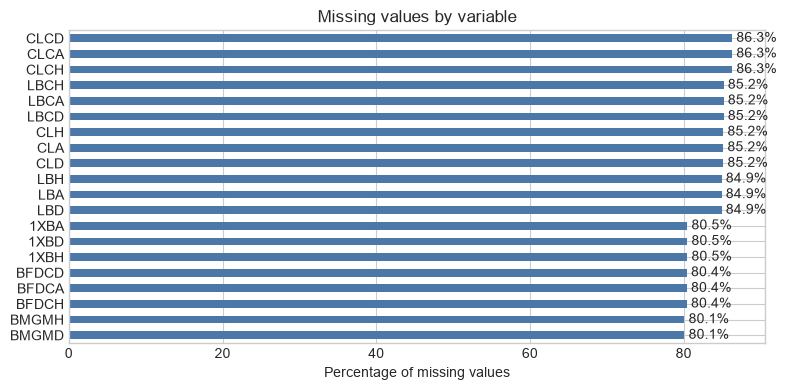

In [795]:
missing_pct = premier_df.isna().mean().mul(100).sort_values().tail(20)

fig, ax = plt.subplots(figsize=(8, 4))
missing_pct.plot(kind="barh", ax=ax, color="#4C78A8")
ax.set(title="Missing values by variable", xlabel="Percentage of missing values", ylabel="")
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)
plt.tight_layout()
plt.show()


# 2. La variable objetivo (el resultado)

Además de ver cómo se reparten los resultados, calculamos un **punto de partida**: un modelo que siempre predice la clase más frecuente (victoria local, `H`) acertaría un 44.2% de las veces. Cualquier modelo tiene que superar ese número. Y como hay tres resultados y no están repartidos por igual, conviene mirar el acierto por separado para cada resultado (local, empate, visitante) en vez de solo el porcentaje total de aciertos.


In [796]:
target_summary = (
    premier_df["FTR"]
    .value_counts()
    .rename(index={"H": "Home Win", "D": "Draw", "A": "Away Win"})
    .to_frame("n")
)
target_summary["pct"] = target_summary["n"].div(len(premier_df)).mul(100)
target_summary


,n,pct
FTR,,
Home Win,839,44.158
Away Win,607,31.947
Draw,454,23.895


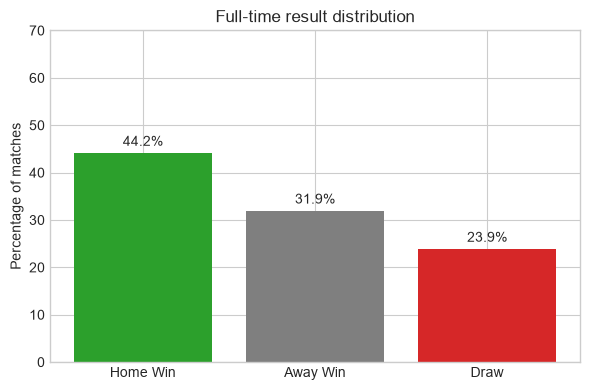

In [797]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(target_summary.index, target_summary["pct"], color=["#2CA02C", "#7F7F7F", "#D62728"])
ax.set(title="Full-time result distribution", ylabel="Percentage of matches", ylim=(0, 70))
ax.bar_label(bars, fmt="%.1f%%", padding=3)
plt.tight_layout()
plt.show()


### Interpretación

- **Observación:** De cada 100 partidos, unos 44 los gana el equipo de casa, unos 32 los gana el visitante y unos 24 acaban en empate.
- **Interpretación:** Se ve claramente que jugar en casa ayuda: el equipo local gana bastante más seguido que el visitante (como 12 de cada 100 partidos más). El empate es lo más raro de todo.
- **Decisión/Hipótesis:** Si tuviéramos que apostar a ciegas, lo más sensato sería decir siempre "gana el de casa", y acertaríamos unas 44 de cada 100 veces. Cualquier modelo tiene que hacerlo mejor que eso. Y como ganar en casa es tan frecuente, conviene mirar cuánto acierta el modelo en cada tipo de resultado (local, empate, visitante), no solo cuántos aciertos tiene en total.


# 3. Categorical variables and match outcome

To avoid misleading interpretations, the following tables report the group size (`n`) and the breakdown of outcomes (`H`, `D`, `A`) together.


In [798]:

def match_outcomes_summary(data, group_cols, target_col):
    """
    Resume la cantidad de partidos y el desglose de resultados (H, D, A) 
    para cualquier agrupación de variables.
    """
    if isinstance(group_cols, str):
        group_cols = [group_cols]
    
    # 1. Agrupamos y contamos las frecuencias de cada clase (H, D, A)
    summary = (
        data.groupby(group_cols, observed=True)[target_col]
        .value_counts()
        .unstack(fill_value=0) # Convierte las filas de clases en columnas
    )
    
    # 2. Calculamos el total de partidos para ese grupo
    summary["Total"] = summary.sum(axis=1)
    
    # 3. Calculamos los porcentajes dinámicamente para cada clase existente
    # Usamos las clases reales encontradas en la tabla pivote
    classes = [col for col in summary.columns if col != "Total"]
    
    for col in classes:
        summary[f"{col}_pct"] = (summary[col] / summary["Total"] * 100).round(2)
        
    return summary

# --- APLICACIÓN ---

# Desglose del resultado final (FTR) por Temporada
season_ftr_summary = match_outcomes_summary(premier_df, "Season", "FTR")

# Desglose del resultado al medio tiempo (HTR) por Temporada
season_htr_summary = match_outcomes_summary(premier_df, "HTR", "FTR")

referee_summary = match_outcomes_summary(premier_df, "Referee", "FTR")

nombre_casa = match_outcomes_summary(premier_df, "HomeTeam", "FTR")
nombre_visitante = match_outcomes_summary(premier_df, "AwayTeam", "FTR")
division_completo = match_outcomes_summary(premier_df, "Div", "FTR")


display(season_ftr_summary)
display(season_htr_summary)
display(referee_summary)
display(nombre_casa)
display(nombre_visitante)
display(division_completo)

FTR,A,D,H,Total,A_pct,D_pct,H_pct
Season,,,,,,,
2021-2022,129,88,163,380,33.950,23.160,42.890
2022-2023,109,87,184,380,28.680,22.890,48.420
2023-2024,123,82,175,380,32.370,21.580,46.050
2024-2025,132,93,155,380,34.740,24.470,40.790
2025-2026,114,104,162,380,30.000,27.370,42.630


FTR,A,D,H,Total,A_pct,D_pct,H_pct
HTR,,,,,,,
A,343,87,60,490,70.000,17.760,12.240
D,210,253,266,729,28.810,34.710,36.490
H,54,114,513,681,7.930,16.740,75.330


FTR,A,D,H,Total,A_pct,D_pct,H_pct
Referee,,,,,,,
A Kitchen,0,3,3,6,0.000,50.000,50.000
A Madley,35,23,46,104,33.650,22.120,44.230
A Marriner,16,6,10,32,50.000,18.750,31.250
A Taylor,54,39,53,146,36.990,26.710,36.300
C Kavanagh,36,28,41,105,34.290,26.670,39.050
C Pawson,40,25,44,109,36.700,22.940,40.370
D Bond,5,6,12,23,21.740,26.090,52.170
D Coote,21,16,26,63,33.330,25.400,41.270
D England,25,23,39,87,28.740,26.440,44.830


FTR,A,D,H,Total,A_pct,D_pct,H_pct
HomeTeam,,,,,,,
Arsenal,12,15,68,95,12.630,15.790,71.580
Aston Villa,22,20,53,95,23.160,21.050,55.790
Bournemouth,24,24,28,76,31.580,31.580,36.840
Brentford,27,29,39,95,28.420,30.530,41.050
Brighton,24,31,40,95,25.260,32.630,42.110
Burnley,31,17,9,57,54.390,29.820,15.790
Chelsea,22,28,45,95,23.160,29.470,47.370
Crystal Palace,28,35,32,95,29.470,36.840,33.680
Everton,38,23,34,95,40.000,24.210,35.790


FTR,A,D,H,Total,A_pct,D_pct,H_pct
AwayTeam,,,,,,,
Arsenal,54,20,21,95,56.840,21.050,22.110
Aston Villa,36,18,41,95,37.890,18.950,43.160
Bournemouth,24,20,32,76,31.580,26.320,42.110
Brentford,29,20,46,95,30.530,21.050,48.420
Brighton,32,28,35,95,33.680,29.470,36.840
Burnley,7,16,34,57,12.280,28.070,59.650
Chelsea,39,22,34,95,41.050,23.160,35.790
Crystal Palace,27,28,40,95,28.420,29.470,42.110
Everton,22,29,44,95,23.160,30.530,46.320


FTR,A,D,H,Total,A_pct,D_pct,H_pct
Div,,,,,,,
E0,607,454,839,1900,31.950,23.890,44.160


In [799]:
columnas_pct = ["H_pct", "D_pct", "A_pct"]
colores = ["#2CA02C", "#7F7F7F", "#D62728"] # Verde (H), Gris (D), Rojo (A)
leyenda_nombres = ["Home Win (H)", "Draw (D)", "Away Win (A)"]

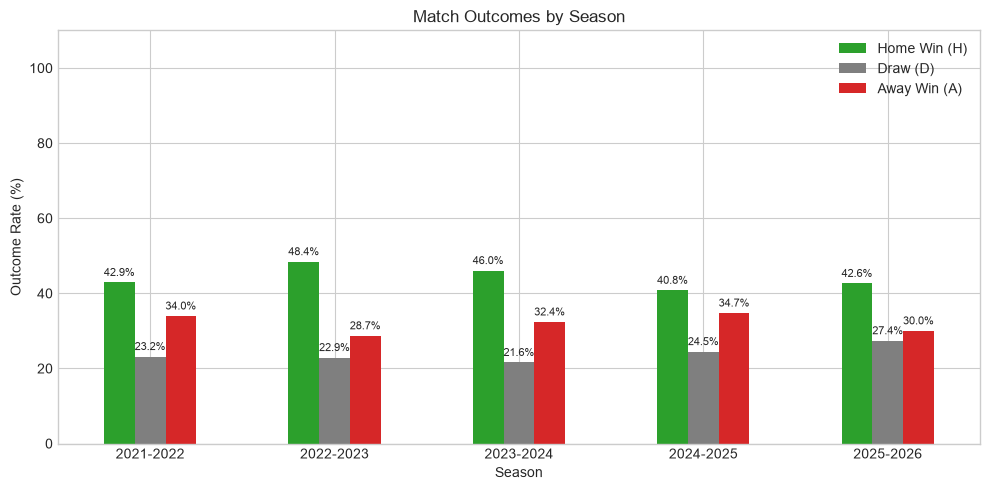

In [800]:
fig, ax = plt.subplots(figsize=(10, 5))

season_ftr_summary[columnas_pct].plot(kind="bar", ax=ax, color=colores, rot=0)
ax.set(title="Match Outcomes by Season", xlabel="Season", ylabel="Outcome Rate (%)", ylim=(0, 110))
ax.legend(leyenda_nombres)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, size=8)

plt.tight_layout()
plt.show()

### Interpretación

- **Observación:** En las 5 temporadas, ganar en casa va de 41 a 48 de cada 100 partidos, el empate de 22 a 27, y ganar fuera de 29 a 35. Cada temporada tiene 380 partidos.
- **Interpretación:** En todas las temporadas el local gana más que el visitante, o sea que la ventaja de casa se mantiene año tras año. Las pequeñas diferencias entre temporadas (unos 4 puntos arriba o abajo) son demasiado chicas como para hablar de una tendencia real: con 380 partidos, un porcentaje puede moverse varios puntos por pura suerte.
- **Decisión/Hipótesis:** La temporada por sí sola no dice mucho. Sirve más para ordenar los datos de forma lógica (por ejemplo, entrenar con los años viejos y comprobar con los nuevos) que para usarla como una pista fuerte para predecir.


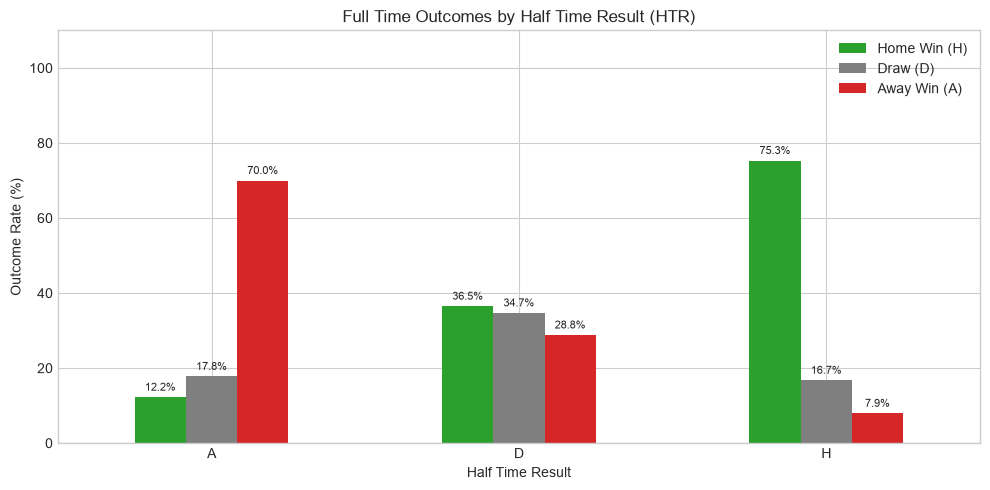

In [801]:
fig, ax = plt.subplots(figsize=(10, 5))

season_htr_summary[columnas_pct].plot(kind="bar", ax=ax, color=colores, rot=0)
ax.set(title="Full Time Outcomes by Half Time Result (HTR)", xlabel="Half Time Result", ylabel="Outcome Rate (%)", ylim=(0, 110))
ax.legend(leyenda_nombres)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, size=8)

plt.tight_layout()
plt.show()

### Interpretación

- **Observación:** Si un equipo va ganando al descanso, gana el partido completo unas 3 de cada 4 veces. Si va perdiendo, acaba perdiendo 7 de cada 10 veces. Y si va empatado, al final puede pasar cualquier cosa (los tres resultados casi a tercios).
- **Interpretación:** Lo que pasa en el primer tiempo se repite muchísimo en el resultado final. Solo 1 de cada 4 partidos le da la vuelta a un marcador que iba a favor de un equipo en el descanso.
- **Decisión/Hipótesis:** Ese dato sería oro para predecir, pero no se puede usar: antes del partido nadie sabe el marcador del descanso. Meterlo en el modelo sería hacer trampa, porque el modelo usaría información que todavía no existe y parecería buenísimo sin serlo. Solo serviría para apostar con el partido ya empezado, no para un pronóstico previo.


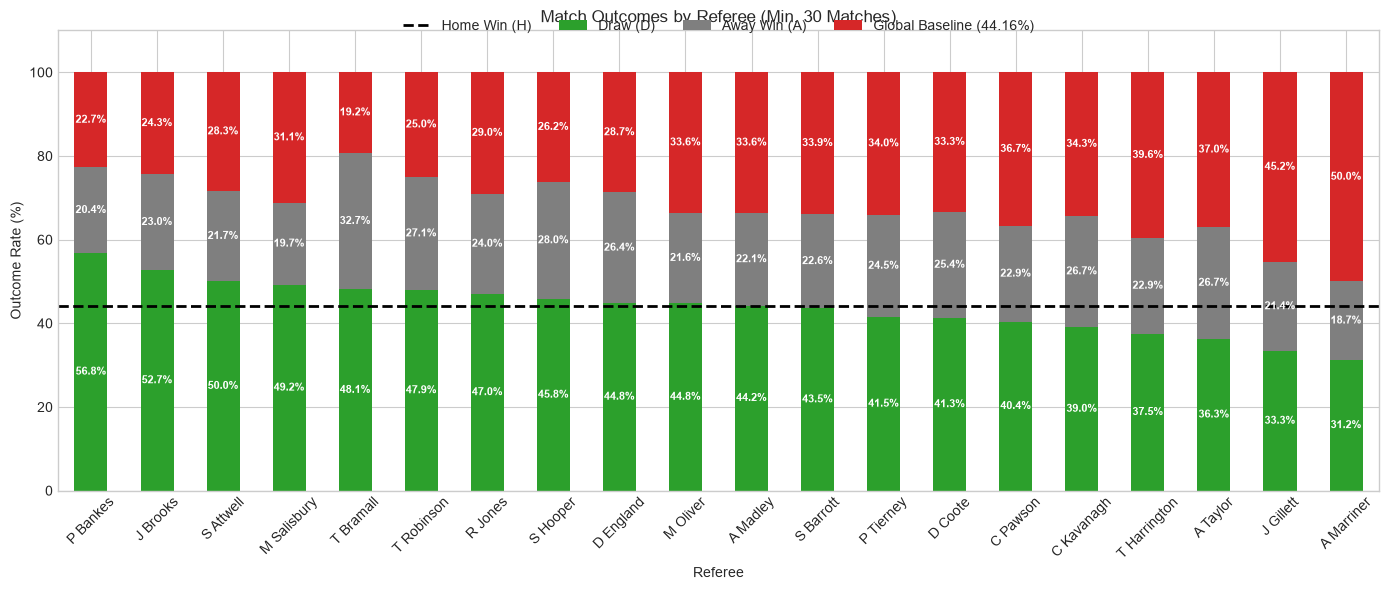

--- Referees with HIGHEST Home Win Rate ---


FTR,A,D,H,Total,A_pct,D_pct,H_pct
Referee,,,,,,,
P Bankes,20,18,50,88,22.730,20.450,56.820
J Brooks,18,17,39,74,24.320,22.970,52.700
S Attwell,30,23,53,106,28.300,21.700,50.000


\n--- Referees with LOWEST Home Win Rate ---


FTR,A,D,H,Total,A_pct,D_pct,H_pct
Referee,,,,,,,
A Taylor,54,39,53,146,36.990,26.710,36.300
J Gillett,38,18,28,84,45.240,21.430,33.330
A Marriner,16,6,10,32,50.000,18.750,31.250


In [802]:
# árbitros con al menos 30 partidos (para significancia estadística)
referees_filtered = referee_summary[referee_summary['Total'] >= 30].copy()

referees_filtered = referees_filtered.sort_values(by="H_pct", ascending=False)

referees_plot_data = referees_filtered[["H_pct", "D_pct", "A_pct"]]

fig, ax = plt.subplots(figsize=(14, 6))

referees_plot_data.plot(kind="bar", stacked=True, ax=ax, color=colores, rot=45)

plt.axhline(y=44.16, color='black', linestyle='--', linewidth=2, label='Global Home Win Baseline (44.16%)')

ax.set(title="Match Outcomes by Referee (Min. 30 Matches)",  xlabel="Referee", ylabel="Outcome Rate (%)", ylim=(0, 110))

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ["Home Win (H)", "Draw (D)", "Away Win (A)", "Global Baseline (44.16%)"], 
          loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=4)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type='center', size=8, color='white', weight='bold')

plt.tight_layout()
plt.show()

#valores extremos
print("--- Referees with HIGHEST Home Win Rate ---")
display(referees_filtered.head(3))
print("\\n--- Referees with LOWEST Home Win Rate ---")
display(referees_filtered.tail(3))

### Conclusión: el árbitro influye poco (y mejor no usarlo)

- **Observación:** Los resultados no son iguales con todos los árbitros: algunos terminan con más victorias de local que otros, incluso mirando solo a los que dirigieron 30 partidos o más.
- **Interpretación:** Esa diferencia no significa que el árbitro decida el resultado. Los árbitros no se reparten al azar (a unos les tocan equipos más fuertes que a otros), y con 40 árbitros, algunos van a parecer "especiales" solo por casualidad. Además, cada árbitro dirige pocos partidos, así que su porcentaje puede cambiar mucho por pura suerte.
- **Decisión/Hipótesis:** Meter al árbitro en el modelo es arriesgado: el modelo podría memorizar coincidencias en vez de aprender algo real. Mejor dejarlo fuera y quedarnos con lo que sí importa (la fuerza de los equipos y las cuotas).


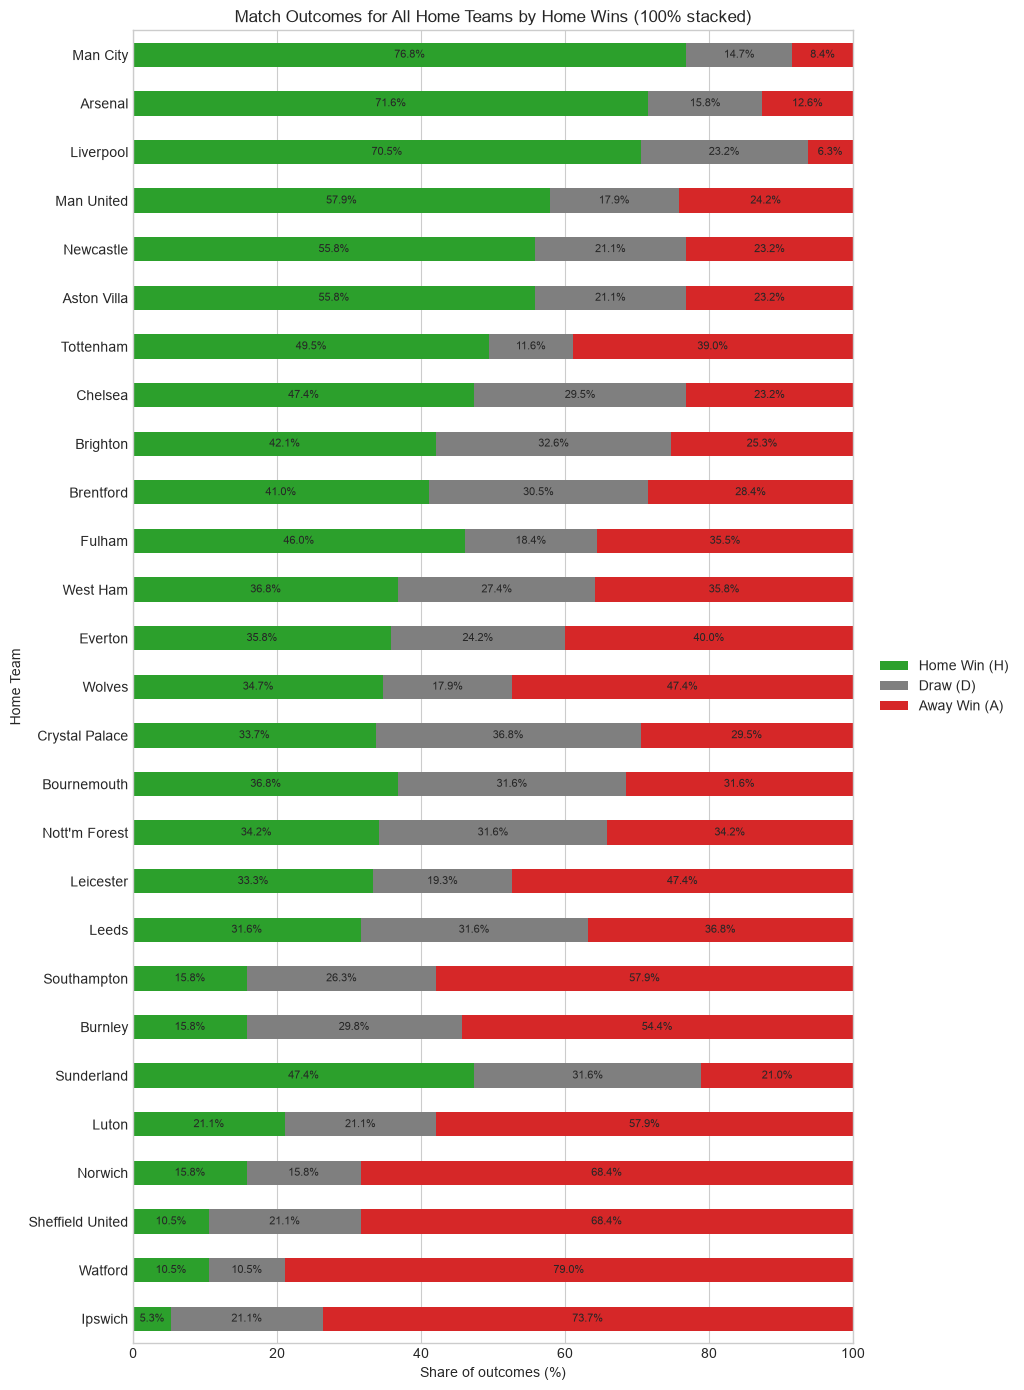

In [803]:
fig, ax = plt.subplots(figsize=(11, 14))

# Todos los equipos ordenados por victorias de local (H): el que más ganó arriba
top_home_teams = nombre_casa.sort_values("H", ascending=False).iloc[::-1]

# Una sola barra horizontal por equipo: en verde gana (H), en rojo pierde (A)
top_home_teams[columnas_pct].plot(kind="barh", stacked=True, ax=ax, color=colores)
ax.set(title="Match Outcomes for All Home Teams by Home Wins (100% stacked)", xlabel="Share of outcomes (%)", ylabel="Home Team", xlim=(0, 100))
ax.legend(leyenda_nombres, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center", size=8)

plt.tight_layout()
fig.subplots_adjust(right=0.78)
plt.show()

### Interpretación

- **Observación:** Los equipos están muy ordenados: los de arriba ganan en casa entre 60 y 70 de cada 100 partidos, y los de abajo entre 20 y 30. El promedio general es 44.
- **Interpretación:** Quién es el equipo de casa importa muchísimo: el orden se parece a la fuerza real de cada equipo, con los grandes arriba y los chicos abajo. Dice bastante más que la temporada o el árbitro.
- **Decisión/Hipótesis:** El equipo es información de verdad y hay que aprovecharla. Pero meter 27 equipos como si fueran 27 cajitas sueltas es muchísimo; mejor resumirlos en un solo número que diga lo bueno que es cada uno (por ejemplo, sus puntos por partido), o dejárselo a las cuotas de apuestas, que ya lo resumen por nosotros.


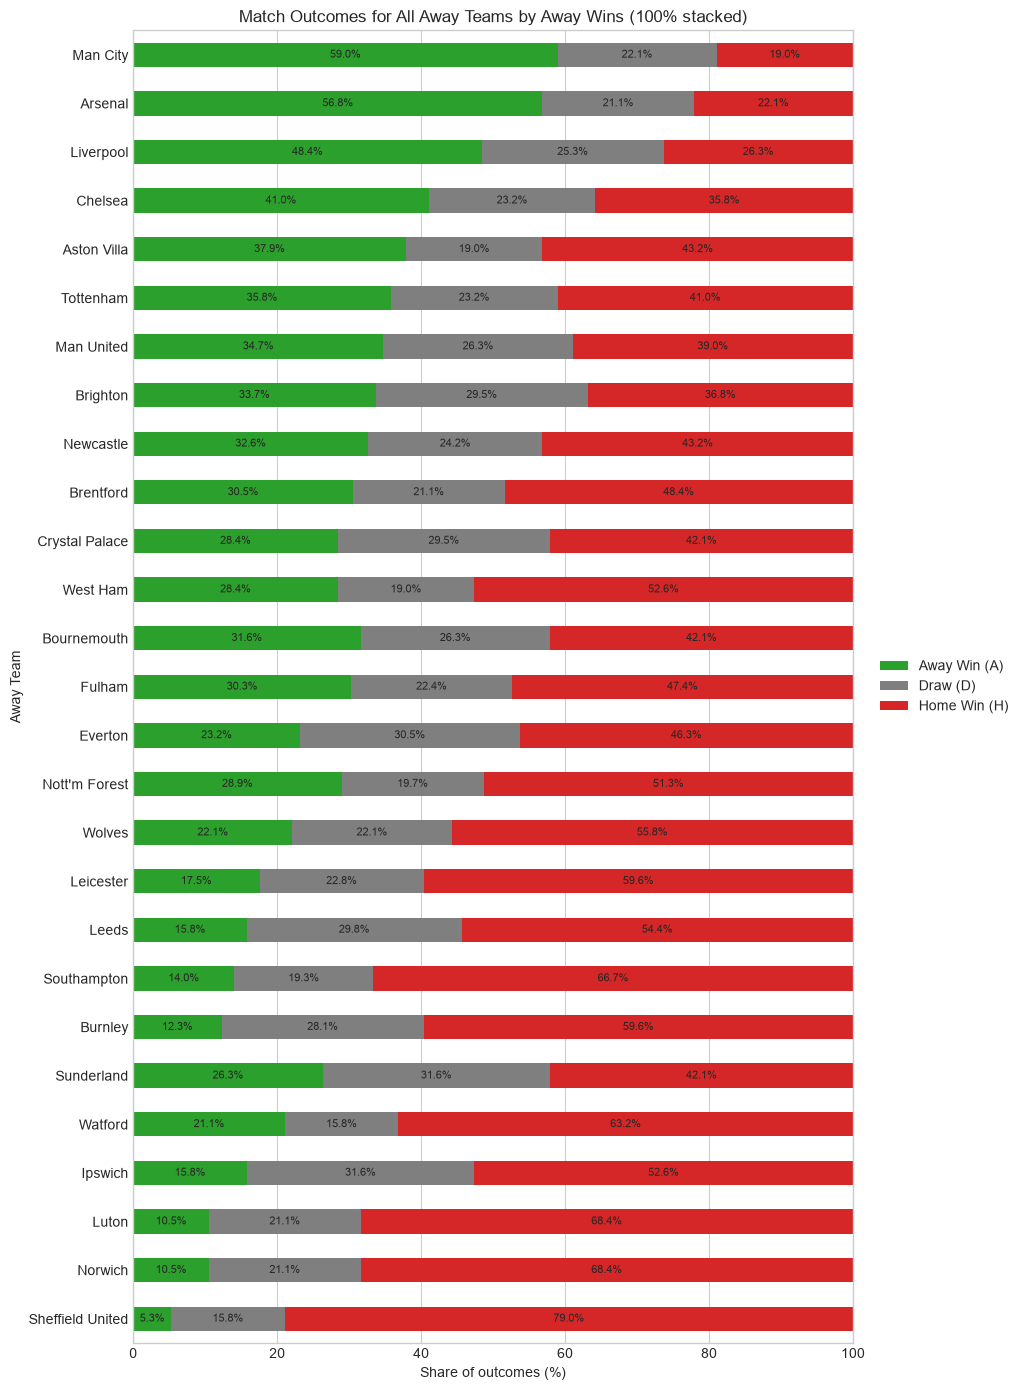

In [804]:
fig, ax = plt.subplots(figsize=(11, 14))

# Todos los equipos ordenados por victorias de visitante (A): el que más ganó arriba
top_away_teams = nombre_visitante.sort_values("A", ascending=False).iloc[::-1]

# Orden lógico para el equipo evaluado (visitante): ganó (A), empató (D), perdió (H)
top_away_teams[["A_pct", "D_pct", "H_pct"]].plot(kind="barh", stacked=True, ax=ax, color=colores)
ax.set(title="Match Outcomes for All Away Teams by Away Wins (100% stacked)", xlabel="Share of outcomes (%)", ylabel="Away Team", xlim=(0, 100))
ax.legend(["Away Win (A)", "Draw (D)", "Home Win (H)"], loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center", size=8)

plt.tight_layout()
fig.subplots_adjust(right=0.78)
plt.show()

### Interpretación

- **Observación:** Como visitante también hay orden entre equipos, pero más apretado: el mejor gana fuera como mucho la mitad de los partidos, y el peor más o menos 15 de cada 100. El centro está en 32.
- **Interpretación:** Jugar fuera hace que las diferencias entre equipos se achiquen: cuesta más ganar de visitante, así que hasta los buenos bajan y todos quedan más juntos. El orden de quién es mejor se mantiene, pero comprimido.
- **Decisión/Hipótesis:** Conviene tratar "lo bueno que es un equipo en casa" y "lo bueno que es fuera" como dos cosas distintas, porque no rinden igual en los dos sitios.


In [805]:
home_team_season_summary = match_outcomes_summary( premier_df, [ "HomeTeam", "Season" ], "FTR")
#display(home_team_season_summary)
away_team_season_summary = match_outcomes_summary( premier_df, [ "AwayTeam", "Season" ], "FTR")
#display(away_team_season_summary)


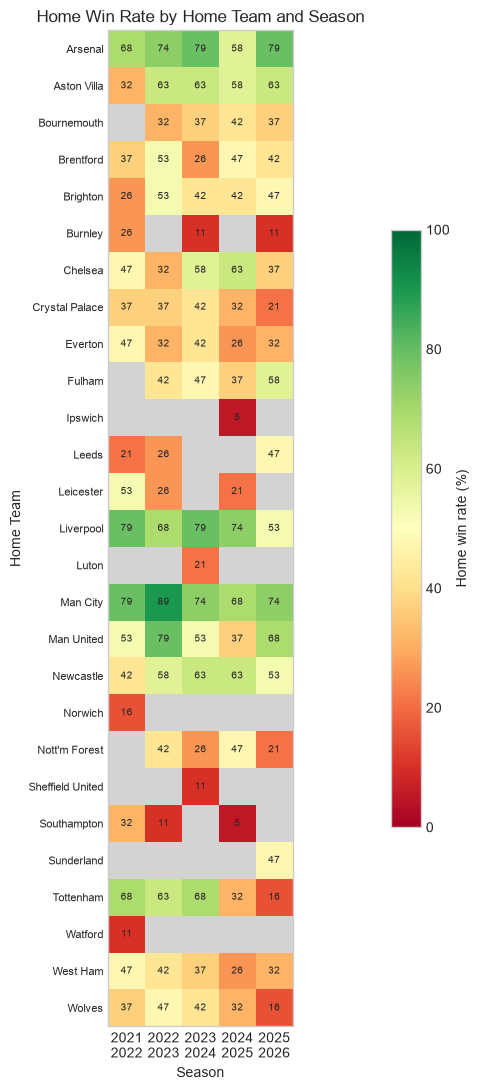

In [806]:
# Chart 1: home win rate by home team and season
home_season_pivot = home_team_season_summary["H_pct"].unstack("Season")

cmap = plt.cm.RdYlGn.copy()
cmap.set_bad("lightgray")

fig, ax = plt.subplots(figsize=(20, 11))
im = ax.imshow(home_season_pivot.values, cmap=cmap, vmin=0, vmax=100)
ax.set_xticks(range(home_season_pivot.shape[1]))
ax.set_xticklabels([c.replace("-", "\n") for c in home_season_pivot.columns], fontsize=10)
ax.set_yticks(range(home_season_pivot.shape[0]))
ax.set_yticklabels(home_season_pivot.index, fontsize=8)
ax.grid(False)
ax.set_title("Home Win Rate by Home Team and Season")
ax.set_xlabel("Season")
ax.set_ylabel("Home Team")

for i in range(home_season_pivot.shape[0]):
    for j in range(home_season_pivot.shape[1]):
        val = home_season_pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=7)

fig.colorbar(im, ax=ax, label="Home win rate (%)", shrink=0.6)
plt.tight_layout()
plt.show()


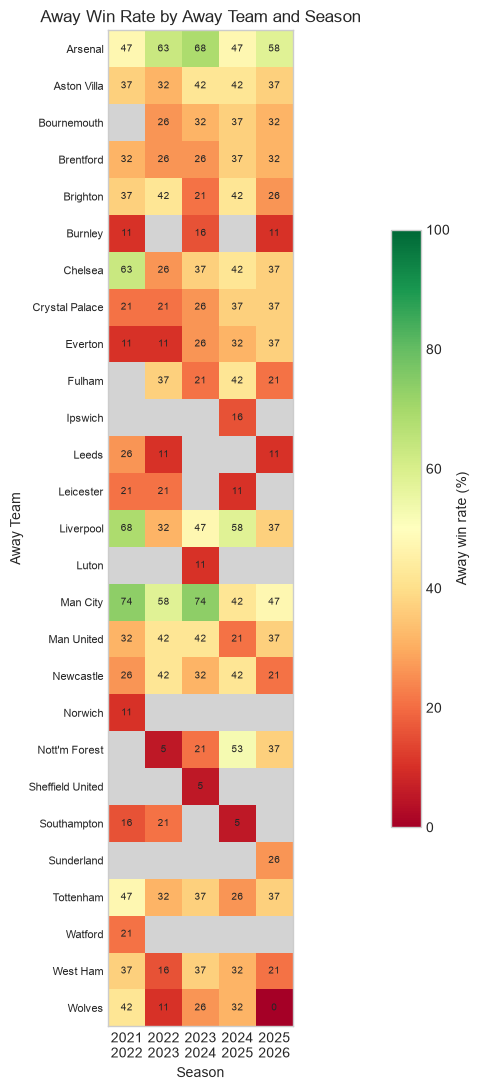

In [807]:
# Chart 2: away win rate by away team and season
away_season_pivot = away_team_season_summary["A_pct"].unstack("Season")

cmap = plt.cm.RdYlGn.copy()
cmap.set_bad("lightgray")

fig, ax = plt.subplots(figsize=(20, 11))
im = ax.imshow(away_season_pivot.values, cmap=cmap, vmin=0, vmax=100)
ax.set_xticks(range(away_season_pivot.shape[1]))
ax.set_xticklabels([c.replace("-", "\n") for c in away_season_pivot.columns], fontsize=10)
ax.set_yticks(range(away_season_pivot.shape[0]))
ax.set_yticklabels(away_season_pivot.index, fontsize=8)
ax.grid(False)
ax.set_title("Away Win Rate by Away Team and Season")
ax.set_xlabel("Season")
ax.set_ylabel("Away Team")

for i in range(away_season_pivot.shape[0]):
    for j in range(away_season_pivot.shape[1]):
        val = away_season_pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=7)

fig.colorbar(im, ax=ax, label="Away win rate (%)", shrink=0.6)
plt.tight_layout()
plt.show()


### Interpretación (mapas de calor: equipo por temporada)

- **Observación:** En el mapa, lo primero que salta a la vista son los huecos: algunos equipos aparecen en todas las temporadas y otros solo en una o dos. Cada equipo juega 19 partidos por temporada.
- **Interpretación:** Los huecos son importantísimos y no son un detalle: los equipos que faltan son los que descendieron a una liga menor (o ascendieron y por eso no están en todas). Y hay una relación muy clara: los equipos que faltan en más temporadas suelen rendir peor. Si ordenamos los equipos por cuántas temporadas llevan en la liga, los que estuvieron las 5 temporadas ganan de media el 44% de sus partidos, mientras que los que solo estuvieron 1 temporada ganan el 17%. Dicho de otra forma: quedarse en la máxima categoría ya dice mucho de lo bueno que es un equipo.
- **Decisión/Hipótesis:** Lo que sí sirve del mapa no es el color de cada casilla (son pocos partidos y se ve mucho ruido), sino el patrón de presencia: cuántas temporadas lleva el equipo en la liga (o si viene de ascender) es una pista simple, potente y conocida antes de cada partido. Esa sí la probaría como característica del modelo.


### Advertencia: porcentajes con pocos partidos

Algunos de estos porcentajes salen de muy pocos partidos, y hay que tomarlos con cuidado por tres motivos.

- **Pocos partidos, mucho azar:** un equipo solo juega 19 partidos por temporada, así que su porcentaje puede cambiar muchísimo por pura suerte. Dos equipos que parecen estar separados por 15 puntos de diferencia pueden ser en realidad igual de buenos, y lo que vemos es solo ruido. Con los árbitros es peor: hay árbitros con 1 partido y otros con 146 (la mayoría ronda los 29), y con menos de 10 partidos su porcentaje es prácticamente una moneda al aire.
- **Mirar los extremos engaña:** si ordenamos unos 27 equipos o unos 40 árbitros y nos fijamos en los de arriba y los de abajo, siempre va a parecer que alguno es "especial", pero parte de eso es pura casualidad.
- **Los árbitros no se reparten al azar:** un árbitro con muchas victorias locales puede haberlas conseguido porque le tocaron rivales débiles, no porque él influya. Además, un equipo con una temporada buenísima (o malísima) tiende a volver hacia el promedio en la siguiente.

*Decisión:* mostrar siempre cuántos partidos hay detrás de cada porcentaje, y solo fiarse de diferencias más grandes que el margen de error que da el azar. En el modelo, tratar al equipo y al árbitro con cuidado (resumirlos o dejarlos fuera) en vez de tratarlos como cajitas sueltas, y usar las cuotas de apuestas como medida de la fuerza de cada equipo, sin meter información que no exista antes del partido.


# 4. Home/Away: la categórica más fuerte

Cada fila ya codifica la localía desde la perspectiva del equipo local: `FTR = H` es victoria local, `A` victoria visitante, `D` empate. Por eso la distribución del target **es** el análisis de Home/Away: el *home advantage* es la diferencia entre `P(H)` y `P(A)`.

Para demostrar que la ventaja local no es un artefacto de 2-3 equipos, comparamos la tasa de victoria **en casa vs fuera** de cada equipo.


In [808]:
# Construimos una tabla larga: cada fila = un equipo en un partido, con su localía
home_part = premier_df[["HomeTeam", "FTR"]].copy()
home_part["venue"] = "Home"
home_part["win"] = home_part["FTR"].eq("H").astype(int)
home_part["draw"] = home_part["FTR"].eq("D").astype(int)
home_part = home_part.rename(columns={"HomeTeam": "team"})

away_part = premier_df[["AwayTeam", "FTR"]].copy()
away_part["venue"] = "Away"
away_part["win"] = away_part["FTR"].eq("A").astype(int)
away_part["draw"] = away_part["FTR"].eq("D").astype(int)
away_part = away_part.rename(columns={"AwayTeam": "team"})

venue_long = pd.concat([home_part, away_part], ignore_index=True)

# Tasa de victoria y puntos por partido (PPG) por localía
home_advantage = venue_long.groupby("venue").agg(
    n=("win", "size"),
    win_pct=("win", lambda s: s.mean() * 100),
    draw_pct=("draw", lambda s: s.mean() * 100),
).round(1)
home_advantage["ppg"] = (3 * home_advantage["win_pct"] / 100 + home_advantage["draw_pct"] / 100).round(2)
home_advantage

# El home advantage como delta de win% y de PPG
delta_win = home_advantage.loc["Home", "win_pct"] - home_advantage.loc["Away", "win_pct"]
delta_ppg = home_advantage.loc["Home", "ppg"] - home_advantage.loc["Away", "ppg"]
print(f"Home advantage (win%): {delta_win:.1f} pp")
print(f"Home advantage (PPG):  {delta_ppg:.2f} ppg")


Home advantage (win%): 12.3 pp
Home advantage (PPG):  0.37 ppg


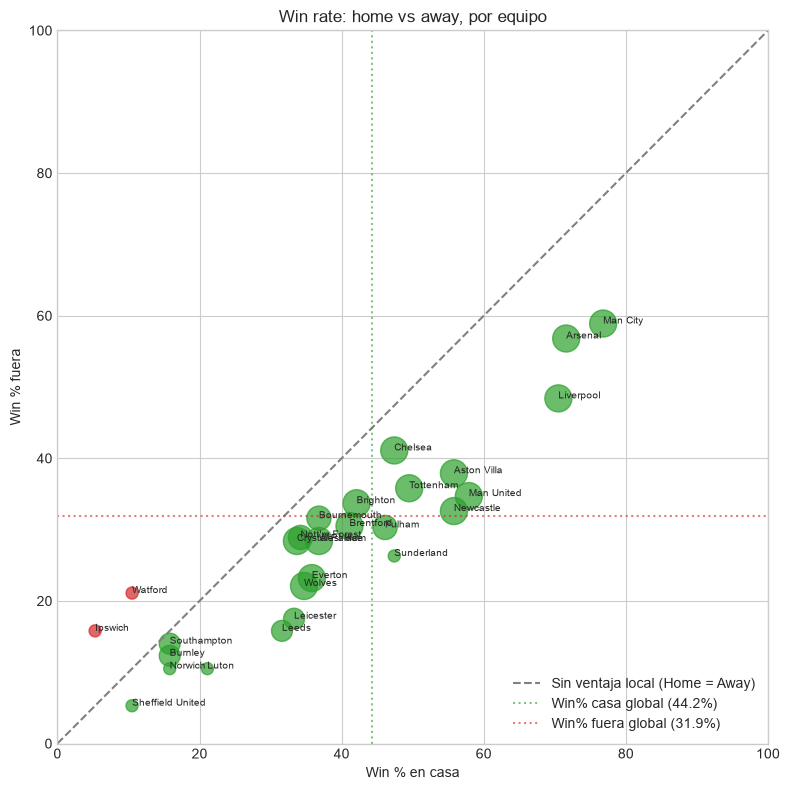

In [809]:
team_n = venue_long.groupby("team")["win"].size()

team_venue = venue_long.groupby(["team", "venue"])["win"].mean().mul(100).round(1).unstack("venue")
team_venue["n"] = team_n

home_global = home_advantage.loc["Home", "win_pct"]
away_global = home_advantage.loc["Away", "win_pct"]

fig, ax = plt.subplots(figsize=(8, 8))
color = ["#2CA02C" if h >= a else "#D62728" for h, a in zip(team_venue["Home"], team_venue["Away"])]
ax.scatter(team_venue["Home"], team_venue["Away"], s=team_venue["n"] * 2, c=color, alpha=0.7)

# Referencias: diagonal (neutral a nivel equipo) y centro poblacional
ax.plot([0, 100], [0, 100], "--", color="gray", label="Sin ventaja local (Home = Away)")
ax.axvline(home_global, color="#2CA02C", linestyle=":", alpha=0.6, label=f"Win% casa global ({home_global:.1f}%)")
ax.axhline(away_global, color="#D62728", linestyle=":", alpha=0.6, label=f"Win% fuera global ({away_global:.1f}%)")

ax.set(
    title="Win rate: home vs away, por equipo",
    xlabel="Win % en casa",
    ylabel="Win % fuera",
    xlim=(0, 100),
    ylim=(0, 100),
)
for team in team_venue.index:
    ax.annotate(team, (team_venue.loc[team, "Home"], team_venue.loc[team, "Away"]), fontsize=7)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


### Interpretación

- **Observación:** En la gráfica de la línea recta, cada punto es un equipo: en horizontal se ve cuánto gana en casa y en vertical cuánto gana fuera. La línea recta que cruza es la frontera donde ganar en casa es igual que ganar fuera: si un punto cayera justo encima de esa línea, a ese equipo le daría exactamente igual jugar de local o de visitante.
- **Interpretación:** Casi todos los puntos están por encima de esa línea. Estar por encima significa que el equipo gana más en casa que fuera. Como les pasa a casi todos, la ventaja de jugar en casa es algo general de toda la liga, no una rareza de uno o dos equipos.
- **Decisión/Hipótesis:** Esa ventaja de casa se puede meter en el modelo como un empujón fijo que se le da al equipo local, o separando lo bueno que es cada equipo en casa y lo bueno que es fuera. Los nombres de equipo se resumen en un número de fuerza, no como 27 cajitas sueltas.


# 5. Variables numéricas: estadísticas del partido y cuotas de las casas

Aquí vemos las variables numéricas, que se dividen en dos grupos:

1. **Estadísticas del partido (16):** goles, tiros, faltas, corners y tarjetas.
   Solo se conocen **después** de que termina el partido.
2. **Cuotas de las casas (132):** los precios que ponen las casas de apuestas
   **antes** del partido.

La pregunta de esta sección: ¿cuáles de estas variables se relacionan con el resultado
(`FTR`) y cuáles no? Las que solo se conocen después del partido no sirven para
predecir; las cuotas, que se conocen antes, sí.

In [810]:
# Clasificamos las columnas numéricas en dos bloques según su rol analítico
match_stats = ["FTHG", "FTAG", "HTHG", "HTAG", "HS", "AS", "HST", "AST",
               "HF", "AF", "HC", "AC", "HY", "AY", "HR", "AR"]

# El bloque de odds son las 132 columnas float64 restantes
odds_cols = premier_df.select_dtypes(include=["float64"]).columns.tolist()

# Resumen: dtype, bloque y % de missing de cada columna numérica
num_summary = pd.DataFrame({
    "dtype": premier_df[match_stats + odds_cols].dtypes,
    "bloque": ["match_stats"] * len(match_stats) + ["odds"] * len(odds_cols),
    "missing_pct": premier_df[match_stats + odds_cols].isna().mean().mul(100),
}).round(2)

print(f"match_stats: {num_summary['bloque'].eq('match_stats').sum()} columnas | "
      f"odds: {num_summary['bloque'].eq('odds').sum()} columnas")
print(f"Missing medio en match_stats: "
      f"{num_summary.loc[num_summary['bloque'] == 'match_stats', 'missing_pct'].mean():.2f}%")
print(f"Missing medio en odds:        "
      f"{num_summary.loc[num_summary['bloque'] == 'odds', 'missing_pct'].mean():.2f}%")
num_summary.head(20)

match_stats: 16 columnas | odds: 132 columnas
Missing medio en match_stats: 0.00%
Missing medio en odds:        34.45%


,dtype,bloque,missing_pct
FTHG,int64,match_stats,0.000
FTAG,int64,match_stats,0.000
HTHG,int64,match_stats,0.000
HTAG,int64,match_stats,0.000
HS,int64,match_stats,0.000
AS,int64,match_stats,0.000
HST,int64,match_stats,0.000
AST,int64,match_stats,0.000
HF,int64,match_stats,0.000
AF,int64,match_stats,0.000


### Las estadísticas del partido son "trampa"

El resultado sale de los goles: si el local anota más, `FTR = H`; si empatan, `D`; si
anota más el visitante, `A`. Entonces, si un modelo usara `FTHG` y `FTAG` para predecir,
estaría copiando la respuesta en vez de aprender.

Lo mismo pasa, aunque menos fuerte, con el resto de estadísticas del partido (tiros,
corners, tarjetas): todas se conocen después del pitido final. **No sirven para un
modelo que predice antes de jugar.**

In [811]:
# Descriptivos del bloque match_stats (todas sin missing: count = 1900 en las 16)
premier_df[match_stats].describe().T

,count,mean,std,min,25%,50%,75%,max
FTHG,1900.000,1.597,1.318,0.000,1.000,1.000,2.000,9.000
FTAG,1900.000,1.329,1.204,0.000,0.000,1.000,2.000,8.000
HTHG,1900.000,0.724,0.849,0.000,0.000,1.000,1.000,5.000
HTAG,1900.000,0.577,0.791,0.000,0.000,0.000,1.000,5.000
HS,1900.000,14.159,5.657,1.000,10.000,14.000,18.000,36.000
AS,1900.000,11.711,5.171,1.000,8.000,11.000,15.000,37.000
HST,1900.000,4.872,2.568,0.000,3.000,5.000,6.000,16.000
AST,1900.000,4.121,2.374,0.000,2.000,4.000,5.000,15.000
HF,1900.000,10.568,3.419,1.000,8.000,10.000,13.000,23.000
AF,1900.000,10.941,3.577,1.000,8.000,11.000,13.000,25.000


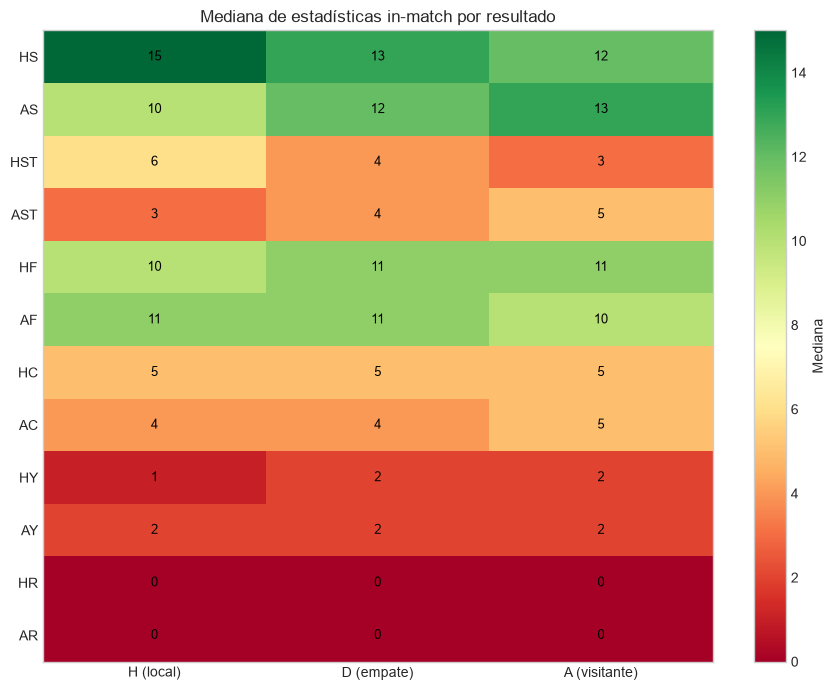

Separación |Mediana H - Mediana A| por estadística:
HS    3.000
AS    3.000
HST   3.000
AST   2.000
HF    1.000
AF    1.000
AC    1.000
HY    1.000
HC    0.000
AY    0.000
HR    0.000
AR    0.000


In [812]:
# Mediana de cada estadística in-match por resultado (H/D/A) — heatmap
stats_12 = ["HS", "AS", "HST", "AST", "HF", "AF", "HC", "AC", "HY", "AY", "HR", "AR"]

medianas = premier_df.groupby("FTR")[stats_12].median().reindex(["H", "D", "A"]).T
medianas = medianas.round(1)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(medianas.values, cmap="RdYlGn", vmin=0, vmax=medianas.values.max(), aspect="auto")
ax.grid(False)
ax.set_xticks(range(3))
ax.set_xticklabels(["H (local)", "D (empate)", "A (visitante)"])
ax.set_yticks(range(len(stats_12)))
ax.set_yticklabels(stats_12)

for i in range(medianas.shape[0]):
    for j in range(medianas.shape[1]):
        ax.text(j, i, f"{medianas.values[i, j]:.0f}", ha="center", va="center",
                fontsize=9, color="black")

fig.colorbar(im, ax=ax, label="Mediana")
ax.set_title("Mediana de estadísticas in-match por resultado")
plt.tight_layout()
plt.show()

# Señal de separación: |mediana H - mediana A| por estadística
sep = (medianas["H"] - medianas["A"]).abs().sort_values(ascending=False)
print("Separación |Mediana H - Mediana A| por estadística:")
print(sep.to_string())

### ¿Qué significa cada estadística?

| Variable | Qué mide |
|---|---|
| `FTHG` / `FTAG` | Goles del local / visitante al final del partido |
| `HTHG` / `HTAG` | Goles del local / visitante al descanso |
| `HS` / `AS` | Tiros (remates) totales del local / visitante |
| `HST` / `AST` | Tiros **a puerta** del local / visitante (los que van entre los tres palos y obligan al portero a intervenir) |
| `HF` / `AF` | Faltas cometidas por el local / visitante |
| `HC` / `AC` | Córners a favor del local / visitante |
| `HY` / `AY` | Tarjetas amarillas del local / visitante |
| `HR` / `AR` | Tarjetas rojas del local / visitante |

La clave para leerlas: un equipo domina el partido cuando remata más, remata **a puerta**
y fuerza más córners en campo rival. Las faltas y tarjetas, en cambio, no dicen quién fue
mejor (a veces hasta las comete el que está perdiendo).

### ¿Qué nos dicen las estadísticas del partido ya jugado?

Estas variables no sirven para **predecir** (se conocen después del pitido final, usarlas
sería trampa), pero sí sirven para **describir** lo que pasó en el partido.

El heatmap de arriba lo muestra:

- Los **tiros a puerta** (`HST`, `AST`) explican el resultado: cuando el local gana tiene
  6 de mediana vs 3 cuando pierde. Un equipo gana porque generó más ocasiones claras.
- Las **faltas, corners y tarjetas** (`HF`, `HC`, `HY`, `HR`) son casi iguales en los
  tres resultados: no explican quién ganó ni por qué.

Entonces, estas estadísticas sirven para analizar un partido que ya pasó (p. ej. "perdimos
porque rematamos poco a puerta"), pero **no para pronosticar el siguiente**. Para eso solo
sirven las cuotas, que se publican antes del partido.

### De la cuota a la probabilidad

Una cuota `2.00` significa que si apostamos 1, nos devuelven 2 si acertamos. La casa le
está dando a ese resultado una probabilidad de `1/2 = 50%`.

Pero las casas cobran un margen: si sumamos las probabilidades de los tres resultados
(H, D, A), da más de 100%. Ese extra es la ganancia de la casa. Para comparar la cuota
con lo que realmente pasó, quitamos ese margen dividiendo cada `1/cuota` entre la suma
de las tres. Así las tres probabilidades suman 100% y podemos contrastarlas con los
resultados reales.

In [813]:
# Overround: 1/H + 1/D + 1/A. Si el mercado fuera "justo" sumaría 1.0;
# el exceso sobre 1.0 es el margen de la casa.
odds_df = premier_df[["B365H", "B365D", "B365A", "AvgH", "AvgD", "AvgA"]].copy()
odds_df["overround_B365"] = 1/odds_df["B365H"] + 1/odds_df["B365D"] + 1/odds_df["B365A"]
odds_df["overround_Avg"]  = 1/odds_df["AvgH"]  + 1/odds_df["AvgD"]  + 1/odds_df["AvgA"]

odds_df[["overround_B365", "overround_Avg"]].agg(["mean", "min", "max"]).round(4)

,overround_B365,overround_Avg
mean,1.054,1.045
min,1.033,1.034
max,1.167,1.073


In [814]:
def implied_prob(h, d, a):
    """Convierte cuotas 1X2 en probabilidades normalizadas (sin overround)."""
    raw = 1/h + 1/d + 1/a
    return 1/h / raw, 1/d / raw, 1/a / raw

# Aplicamos la función a B365 y a Avg en un DataFrame temporal (no tocamos premier_df)
probs_df = premier_df[["B365H", "B365D", "B365A", "AvgH", "AvgD", "AvgA", "FTR"]].copy()
probs_df[["pB365_H", "pB365_D", "pB365_A"]] = probs_df.apply(
    lambda r: implied_prob(r["B365H"], r["B365D"], r["B365A"]), axis=1, result_type="expand")
probs_df[["pAvg_H", "pAvg_D", "pAvg_A"]] = probs_df.apply(
    lambda r: implied_prob(r["AvgH"], r["AvgD"], r["AvgA"]), axis=1, result_type="expand")

# Sanidad: cada fila debe sumar 1.0
print("Suma por fila (debe ser 1.0):")
print(probs_df[["pB365_H", "pB365_D", "pB365_A"]].sum(axis=1).describe().round(6))
probs_df[["pB365_H", "pAvg_H"]].describe().T.round(4)

Suma por fila (debe ser 1.0):
count   1900.000
mean       1.000
std        0.000
min        1.000
25%        1.000
50%        1.000
75%        1.000
max        1.000
dtype: float64


,count,mean,std,min,25%,50%,75%,max
pB365_H,1900.000,0.440,0.192,0.050,0.292,0.426,0.580,0.894
pAvg_H,1900.000,0.441,0.193,0.053,0.294,0.424,0.581,0.899


Baseline (siempre local): 44.2%


,casa,n,acierto_op,fallo_op,acierto_cl,fallo_cl,delta
0,B365,1900,55.300,44.700,55.900,44.100,0.600
7,Avg,1900,55.300,44.700,55.900,44.100,0.600
6,Max,1900,55.200,44.800,55.700,44.300,0.600
1,BW,1747,55.200,44.800,55.500,44.500,0.300
3,PS,1730,56.100,43.900,56.400,43.600,0.200
5,BV,1510,55.600,44.400,55.700,44.300,0.100
4,WH,1429,56.800,43.200,57.000,43.000,0.300
2,IW,955,57.200,42.800,57.400,42.600,0.200


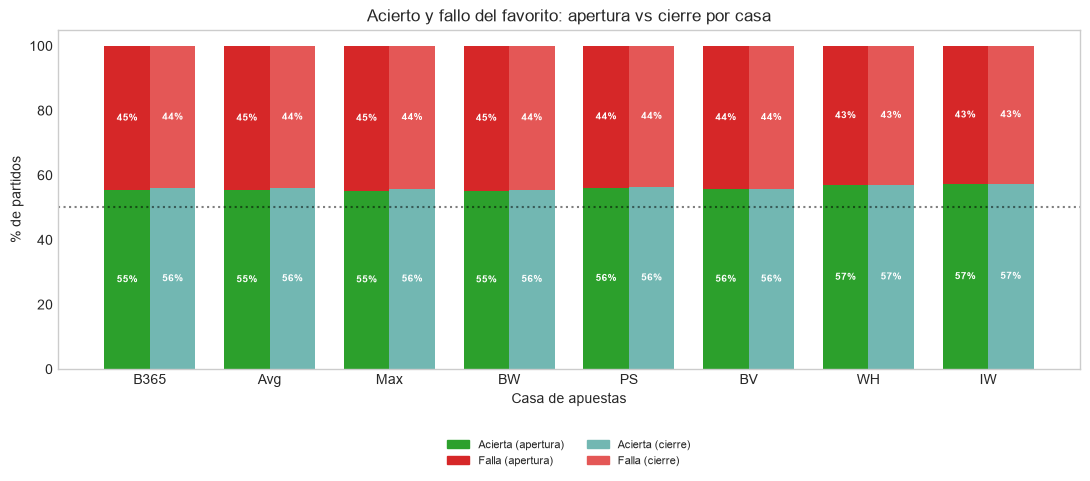

In [815]:
# Apertura vs cierre: ¿cuándo acierta la casa y cuándo falla?
# Apertura = cuota publicada días antes. Cierre = cuota justo antes del pitido.
# Para cada casa, medimos acierto Y fallo con apertura y con cierre.
casas = {
    "B365": ("B365H","B365D","B365A","B365CH","B365CD","B365CA"),
    "BW":   ("BWH","BWD","BWA","BWCH","BWCD","BWCA"),
    "IW":   ("IWH","IWD","IWA","IWCH","IWCD","IWCA"),
    "PS":   ("PSH","PSD","PSA","PSCH","PSCD","PSCA"),
    "WH":   ("WHH","WHD","WHA","WHCH","WHCD","WHCA"),
    "BV":   ("BVH","BVD","BVA","BVCH","BVCD","BVCA"),
    "Max":  ("MaxH","MaxD","MaxA","MaxCH","MaxCD","MaxCA"),
    "Avg":  ("AvgH","AvgD","AvgA","AvgCH","AvgCD","AvgCA"),
}

rows = []
for casa, (h, d, a, ch, cd, ca) in casas.items():
    sub = premier_df[[h, d, a, ch, cd, ca, "FTR"]].dropna().copy()
    fav_op = sub[[h, d, a]].idxmin(axis=1).map({h: "H", d: "D", a: "A"})
    fav_cl = sub[[ch, cd, ca]].idxmin(axis=1).map({ch: "H", cd: "D", ca: "A"})
    acc_op = (fav_op == sub["FTR"]).mean() * 100
    acc_cl = (fav_cl == sub["FTR"]).mean() * 100
    rows.append({"casa": casa, "n": len(sub),
                 "acierto_op": round(acc_op, 1), "fallo_op": round(100 - acc_op, 1),
                 "acierto_cl": round(acc_cl, 1), "fallo_cl": round(100 - acc_cl, 1),
                 "delta": round(acc_cl - acc_op, 1)})

resumen = pd.DataFrame(rows).sort_values("n", ascending=False)
print("Baseline (siempre local): %.1f%%" % (premier_df["FTR"].eq("H").mean() * 100))
display(resumen)

# Gráfica: barras apiladas lado a lado (verde=acierta, rojo=falla) × 2 (apertura, cierre)
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(resumen))
ancho = 0.38
ax.grid(False)

# Apertura: verde abajo, rojo arriba
b_op_a = ax.bar(x - ancho/2, resumen["acierto_op"], ancho, color="#2CA02C")
b_op_f = ax.bar(x - ancho/2, resumen["fallo_op"], ancho, bottom=resumen["acierto_op"], color="#D62728")
# Cierre: verde abajo, rojo arriba
b_cl_a = ax.bar(x + ancho/2, resumen["acierto_cl"], ancho, color="#72B7B2")
b_cl_f = ax.bar(x + ancho/2, resumen["fallo_cl"], ancho, bottom=resumen["acierto_cl"], color="#E45756")

# Etiquetas de % dentro de cada segmento
for i in range(len(resumen)):
    ax.text(x[i] - ancho/2, resumen["acierto_op"].iloc[i]/2, f"{resumen['acierto_op'].iloc[i]:.0f}%",
            ha="center", va="center", fontsize=7, color="white", weight="bold")
    ax.text(x[i] - ancho/2, resumen["acierto_op"].iloc[i] + resumen["fallo_op"].iloc[i]/2,
            f"{resumen['fallo_op'].iloc[i]:.0f}%", ha="center", va="center", fontsize=7, color="white", weight="bold")
    ax.text(x[i] + ancho/2, resumen["acierto_cl"].iloc[i]/2, f"{resumen['acierto_cl'].iloc[i]:.0f}%",
            ha="center", va="center", fontsize=7, color="white", weight="bold")
    ax.text(x[i] + ancho/2, resumen["acierto_cl"].iloc[i] + resumen["fallo_cl"].iloc[i]/2,
            f"{resumen['fallo_cl'].iloc[i]:.0f}%", ha="center", va="center", fontsize=7, color="white", weight="bold")

ax.axhline(50, color="black", linestyle=":", alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(resumen["casa"])
ax.set(xlabel="Casa de apuestas", ylabel="% de partidos", ylim=(0, 105),
       title="Acierto y fallo del favorito: apertura vs cierre por casa")
handles = [plt.Rectangle((0,0),1,1,color=c) for c in ["#2CA02C","#D62728","#72B7B2","#E45756"]]
labels = ["Acierta (apertura)", "Falla (apertura)", "Acierta (cierre)", "Falla (cierre)"]
ax.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

### El cierre acierta igual o más que la apertura

- **Observación:** En las 8 casas completas, la cuota de **cierre** (justo antes del
  pitido) acierta igual o un poco más que la de apertura: B365 55.3→55.9 (+0.6),
  Avg 55.3→55.9 (+0.6), BW 55.2→55.5 (+0.3), WH 56.8→57.0 (+0.3). Ninguna casa
  empeora al cierre. Los fallos (rojo) se reducen en la misma proporción.
- **Interpretación:** El mercado ajusta la cuota entre apertura y cierre con información
  nueva (lesiones, alineaciones, dinero), pero el cambio es pequeño (~0.5 puntos
  porcentuales en promedio). La apertura ya es casi tan buena como el cierre.
- **Decisión/Hipótesis:** usar las cuotas de **cierre** (`*C`) como características del
  modelo, por ser las más informativas. La apertura es casi equivalente si por algún
  motivo no hubiera datos de cierre.

Baseline (siempre local): 44.2%


,cat,n,acierto_op,acierto_cl,fallo_op,fallo_cl,delta
0,Caso improbable (<1.5),465,74.200,74.200,25.800,25.800,0.000
1,Contendiente seguro (1.5-2),679,55.700,55.700,44.300,44.300,0.000
2,Partido parejo (2-3),756,43.400,45.000,56.600,55.000,1.600


Partidos con datos de las 8 casas: 956
Coincidencia entre las 8 casas: 83% todas, 91% 7+, 95% 6+


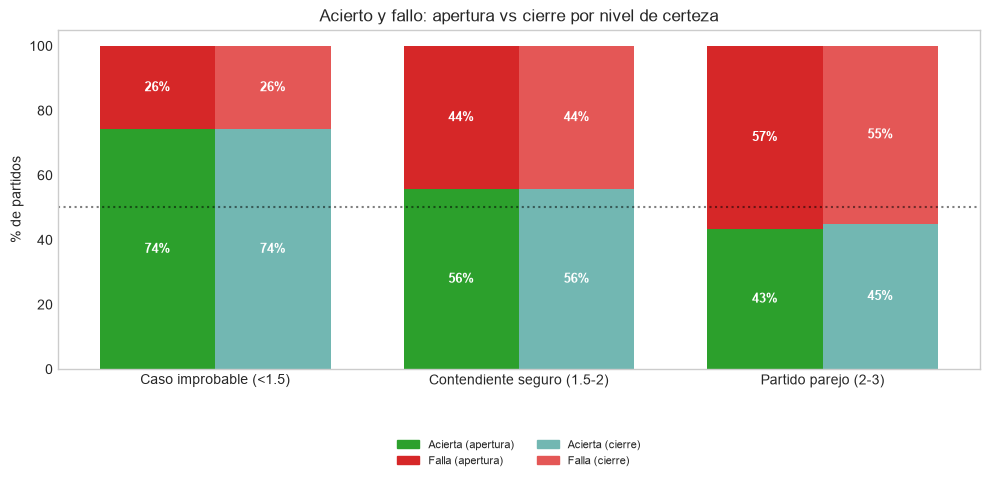

In [816]:
# General: apertura vs cierre según el nivel de certeza del partido
# Usamos Avg (mercado promedio). Clasificamos por cuota del favorito de APERTURA
# en 3 categorías, y medimos acierto Y fallo con apertura y con cierre.
casas_completas = {
    "B365": ("B365H","B365D","B365A","B365CH","B365CD","B365CA"),
    "BW":   ("BWH","BWD","BWA","BWCH","BWCD","BWCA"),
    "IW":   ("IWH","IWD","IWA","IWCH","IWCD","IWCA"),
    "PS":   ("PSH","PSD","PSA","PSCH","PSCD","PSCA"),
    "WH":   ("WHH","WHD","WHA","WHCH","WHCD","WHCA"),
    "BV":   ("BVH","BVD","BVA","BVCH","BVCD","BVCA"),
    "Max":  ("MaxH","MaxD","MaxA","MaxCH","MaxCD","MaxCA"),
    "Avg":  ("AvgH","AvgD","AvgA","AvgCH","AvgCD","AvgCA"),
}

sub = premier_df[["AvgH","AvgD","AvgA","AvgCH","AvgCD","AvgCA","FTR"]].dropna().copy()
sub["cat"] = pd.cut(sub[["AvgH","AvgD","AvgA"]].min(axis=1),
                     bins=[1, 1.5, 2, 3],
                     labels=["Caso improbable (<1.5)", "Contendiente seguro (1.5-2)", "Partido parejo (2-3)"],
                     include_lowest=True)
fav_op = sub[["AvgH","AvgD","AvgA"]].idxmin(axis=1).map({"AvgH":"H","AvgD":"D","AvgA":"A"})
fav_cl = sub[["AvgCH","AvgCD","AvgCA"]].idxmin(axis=1).map({"AvgCH":"H","AvgCD":"D","AvgCA":"A"})
sub["acc_op"] = (fav_op == sub["FTR"]).astype(int)
sub["acc_cl"] = (fav_cl == sub["FTR"]).astype(int)

agregado = sub.groupby("cat", observed=True).agg(
    n=("acc_op", "size"),
    acierto_op=("acc_op", lambda x: round(x.mean() * 100, 1)),
    acierto_cl=("acc_cl", lambda x: round(x.mean() * 100, 1)),
).reset_index()
agregado["fallo_op"] = (100 - agregado["acierto_op"]).round(1)
agregado["fallo_cl"] = (100 - agregado["acierto_cl"]).round(1)
agregado["delta"] = (agregado["acierto_cl"] - agregado["acierto_op"]).round(1)
print("Baseline (siempre local): %.1f%%" % (premier_df["FTR"].eq("H").mean() * 100))
display(agregado)

# Coincidencia entre casas (solo en partidos donde las 8 tienen datos)
cats_matrix = pd.DataFrame({
    casa: pd.cut(premier_df[[h, d, a]].min(axis=1), bins=[1, 1.5, 2, 3],
                 labels=["Caso improbable (<1.5)", "Contendiente seguro (1.5-2)", "Partido parejo (2-3)"],
                 include_lowest=True)
    for casa, (h, d, a, _, _, _) in casas_completas.items()
})
cats_completo = cats_matrix.dropna()
moda = cats_completo.mode(axis=1).iloc[:, 0]
pct_coinciden = cats_completo.eq(moda, axis=0).sum(axis=1)
print("Partidos con datos de las 8 casas: %d" % len(cats_completo))
print("Coincidencia entre las 8 casas: %.0f%% todas, %.0f%% 7+, %.0f%% 6+" %
      ((pct_coinciden == 8).mean() * 100,
       (pct_coinciden >= 7).mean() * 100,
       (pct_coinciden >= 6).mean() * 100))

# Gráfica: barras apiladas lado a lado por categoría
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(agregado))
ancho = 0.38
ax.grid(False)

# Apertura
b_op_a = ax.bar(x - ancho/2, agregado["acierto_op"], ancho, color="#2CA02C")
b_op_f = ax.bar(x - ancho/2, agregado["fallo_op"], ancho, bottom=agregado["acierto_op"], color="#D62728")
# Cierre
b_cl_a = ax.bar(x + ancho/2, agregado["acierto_cl"], ancho, color="#72B7B2")
b_cl_f = ax.bar(x + ancho/2, agregado["fallo_cl"], ancho, bottom=agregado["acierto_cl"], color="#E45756")

for i in range(len(agregado)):
    ax.text(x[i] - ancho/2, agregado["acierto_op"].iloc[i]/2, f"{agregado['acierto_op'].iloc[i]:.0f}%",
            ha="center", va="center", fontsize=9, color="white", weight="bold")
    ax.text(x[i] - ancho/2, agregado["acierto_op"].iloc[i] + agregado["fallo_op"].iloc[i]/2,
            f"{agregado['fallo_op'].iloc[i]:.0f}%", ha="center", va="center", fontsize=9, color="white", weight="bold")
    ax.text(x[i] + ancho/2, agregado["acierto_cl"].iloc[i]/2, f"{agregado['acierto_cl'].iloc[i]:.0f}%",
            ha="center", va="center", fontsize=9, color="white", weight="bold")
    ax.text(x[i] + ancho/2, agregado["acierto_cl"].iloc[i] + agregado["fallo_cl"].iloc[i]/2,
            f"{agregado['fallo_cl'].iloc[i]:.0f}%", ha="center", va="center", fontsize=9, color="white", weight="bold")

ax.axhline(50, color="black", linestyle=":", alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(agregado["cat"], fontsize=10)
ax.set(xlabel="", ylabel="% de partidos", ylim=(0, 105),
       title="Acierto y fallo: apertura vs cierre por nivel de certeza")
handles = [plt.Rectangle((0,0),1,1,color=c) for c in ["#2CA02C","#D62728","#72B7B2","#E45756"]]
labels = ["Acierta (apertura)", "Falla (apertura)", "Acierta (cierre)", "Falla (cierre)"]
ax.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

### El cierre mejora en los partidos más parejos

- **Observación:** En las 3 categorías, el cierre **iguala o mejora** la apertura.
  Los partidos parejos (cuota 2-3) son donde más se nota: acierto 43→45% (+1.6pp),
  fallas 57→55%. En los otros dos el cambio es ~0, porque la apertura ya era acertada.
- **Interpretación:** el mercado se "aclara" más en los partidos donde al principio no
  sabía quién ganar. En los claros, la cuota apenas cambia porque ya estaba bien desde
  el inicio.
- **Decisión/Hipótesis:** usar las cuotas de cierre (`*C`) como características del
  modelo. La apertura es casi equivalente y puede servir como alternativa si no hay datos
  de cierre.

### No todas las casas tienen datos en todas las temporadas

Mucha de la información que falta en las cuotas no es un error: es que **la casa no
operaba** en esa temporada. `B365`, `Max` y `Avg` están en las 5 temporadas; otras solo
en 1 o 2. Por ejemplo, `CL` y `LB` solo tienen datos de 2025-26.

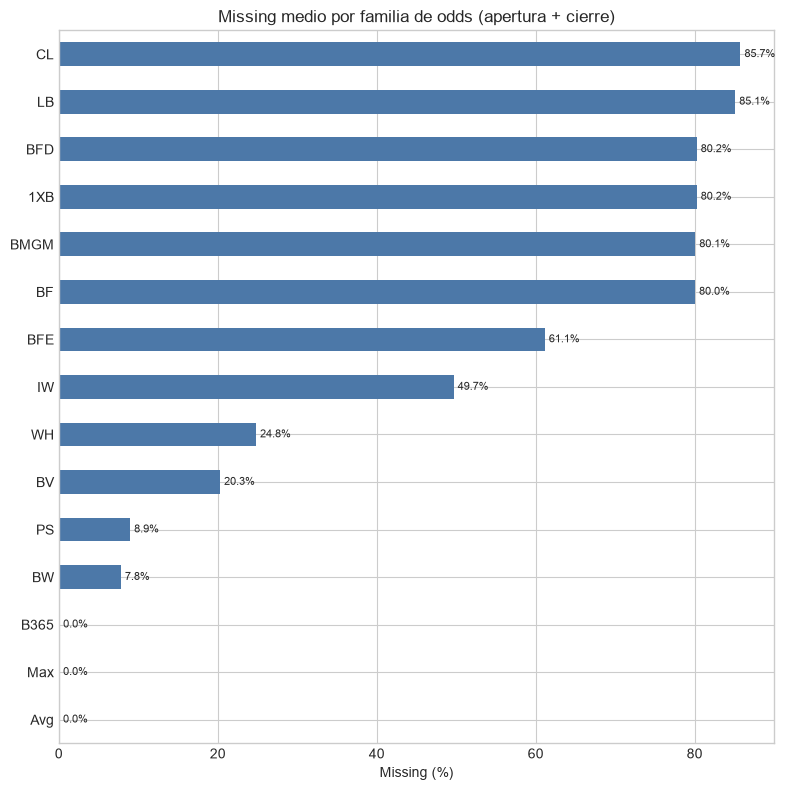

In [817]:
# Missing medio por familia de odds (agrupando por casa de apertura y su variante "C")
familias = {
    "B365": ["B365H", "B365D", "B365A", "B365>2.5", "B365<2.5", "B365AHH", "B365AHA",
             "B365CH", "B365CD", "B365CA", "B365C>2.5", "B365C<2.5", "B365CAHH", "B365CAHA"],
    "BW":   ["BWH", "BWD", "BWA", "BWCH", "BWCD", "BWCA"],
    "IW":   ["IWH", "IWD", "IWA", "IWCH", "IWCD", "IWCA"],
    "PS":   ["PSH", "PSD", "PSA", "PSCH", "PSCD", "PSCA"],
    "WH":   ["WHH", "WHD", "WHA", "WHCH", "WHCD", "WHCA"],
    "BV":   ["BVH", "BVD", "BVA", "BVCH", "BVCD", "BVCA"],
    "Max":  ["MaxH", "MaxD", "MaxA", "Max>2.5", "Max<2.5", "MaxAHH", "MaxAHA",
             "MaxCH", "MaxCD", "MaxCA", "MaxC>2.5", "MaxC<2.5", "MaxCAHH", "MaxCAHA"],
    "Avg":  ["AvgH", "AvgD", "AvgA", "Avg>2.5", "Avg<2.5", "AvgAHH", "AvgAHA",
             "AvgCH", "AvgCD", "AvgCA", "AvgC>2.5", "AvgC<2.5", "AvgCAHH", "AvgCAHA"],
    "BF":   ["BFH", "BFD", "BFA", "BFCH", "BFCD", "BFCA"],
    "1XB":  ["1XBH", "1XBD", "1XBA", "1XBCH", "1XBCD", "1XBCA"],
    "BFE":  ["BFEH", "BFED", "BFEA", "BFE>2.5", "BFE<2.5", "BFEAHH", "BFEAHA",
             "BFECH", "BFECD", "BFECA", "BFEC>2.5", "BFEC<2.5", "BFECAHH", "BFECAHA"],
    "BFD":  ["BFDH", "BFDD", "BFDA", "BFDCH", "BFDCD", "BFDCA"],
    "BMGM": ["BMGMH", "BMGMD", "BMGMA", "BMGMCH", "BMGMCD", "BMGMCA"],
    "CL":   ["CLH", "CLD", "CLA", "CLCH", "CLCD", "CLCA"],
    "LB":   ["LBH", "LBD", "LBA", "LBCH", "LBCD", "LBCA"],
}

missing_fam = pd.DataFrame({
    fam: premier_df[cols].isna().mean().mul(100).mean()
    for fam, cols in familias.items()
}, index=["missing_pct"]).T.sort_values("missing_pct")

fig, ax = plt.subplots(figsize=(8, 8))
missing_fam["missing_pct"].plot(kind="barh", ax=ax, color="#4C78A8")
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3, size=8)
ax.set(xlabel="Missing (%)", title="Missing medio por familia de odds (apertura + cierre)")
plt.tight_layout()
plt.show()

In [818]:
# Cobertura por temporada: % de filas no nulas de una columna representativa por casa
rep_cols = ["B365H", "BWH", "IWH", "PSH", "WHH", "BVH", "BFH", "1XBH",
            "BFEH", "CLH", "LBH", "BFDH", "BMGMH"]

tabla_cobertura = (premier_df.groupby("Season")[rep_cols]
                   .apply(lambda g: g.notna().mean().mul(100).round(1)).T)
tabla_cobertura

Season,2021-2022,2022-2023,2023-2024,2024-2025,2025-2026
B365H,100.000,100.000,100.000,100.000,100.000
BWH,100.000,100.000,99.500,62.900,100.000
IWH,100.000,100.000,52.100,0.000,0.000
PSH,100.000,100.000,100.000,100.000,55.300
WHH,100.000,100.000,100.000,76.100,0.000
BVH,100.000,100.000,100.000,0.000,99.500
BFH,0.000,0.000,0.000,99.700,0.000
1XBH,0.000,0.000,0.000,97.600,0.000
BFEH,0.000,0.000,0.000,100.000,94.700
CLH,0.000,0.000,0.000,0.000,74.200


### La información que falta es porque la casa no existía

- **Observación:** La cobertura es un escalón: casas con ~100% de los partidos en unas
  temporadas y 0% en otras. Las familias con poca cobertura superan el 80% de datos
  faltantes (`BF`, `1XB`, `CL`, `LB`, `BFD`, `BMGM`).
- **Interpretación:** Inventar esos valores (imputar) sería falso: la casa no cotizó esos
  partidos, no es que falte un dato al azar.
- **Decisión/Hipótesis:** no imputar. En modelado se decide si se usan solo las casas con
  buena cobertura o se trabaja con lo disponible.

### Todas las casas dicen lo mismo

Las casas fijan sus cuotas mirando el mismo mercado, así que sus precios deberían ser
casi iguales. Si es así, no necesitamos las 132 columnas: con el promedio (`Avg`), el
máximo (`Max`) y una casa de referencia (B365) alcanza.

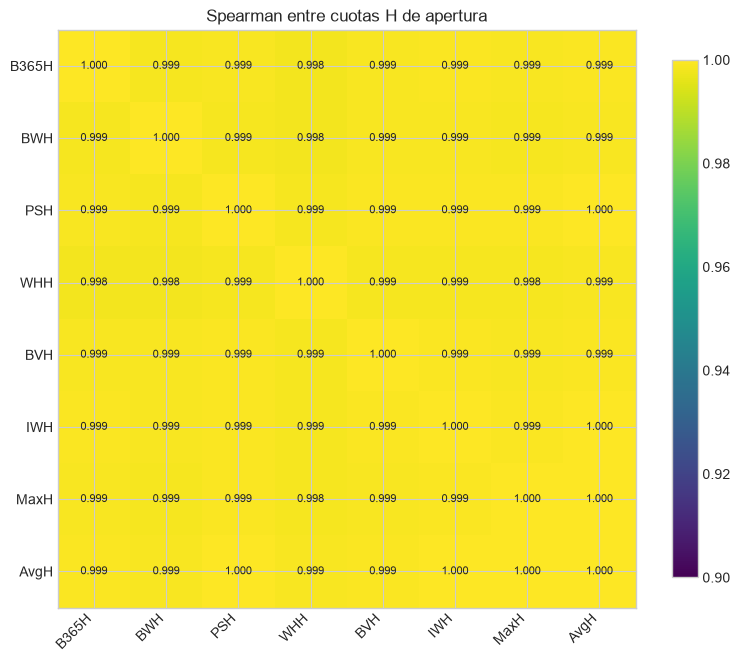

In [819]:
# Matriz de correlación de Spearman entre cuotas H de apertura (anotada)
def spearman_r(x, y):
    rx = pd.Series(np.asarray(x, dtype=float).ravel()).rank(method="average")
    ry = pd.Series(np.asarray(y, dtype=float).ravel()).rank(method="average")
    return rx.corr(ry)

corr_cols = ["B365H", "BWH", "PSH", "WHH", "BVH", "IWH", "MaxH", "AvgH"]
mat_spearman = pd.DataFrame(index=corr_cols, columns=corr_cols, dtype=float)
for c1 in corr_cols:
    for c2 in corr_cols:
        valid = premier_df[[c1, c2]].dropna()
        mat_spearman.loc[c1, c2] = spearman_r(valid[c1], valid[c2])

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(mat_spearman.astype(float).values, vmin=0.9, vmax=1.0, cmap="viridis")
ax.set_xticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols)))
ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{mat_spearman.iloc[i, j]:.3f}",
                ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Spearman entre cuotas H de apertura")
plt.tight_layout()
plt.show()

In [820]:
# Casas de alta missing: ¿aportan información nueva o repiten a AvgH?
# Se correlaciona sobre el subconjunto no nulo de cada una (fair comparison).
def spearman_r(x, y):
    rx = pd.Series(np.asarray(x, dtype=float).ravel()).rank(method="average")
    ry = pd.Series(np.asarray(y, dtype=float).ravel()).rank(method="average")
    return rx.corr(ry)

altas_missing = ["BFH", "1XBH", "CLH", "LBH", "BFDH", "BMGMH"]
for col in altas_missing:
    valid = premier_df[[col, "AvgH"]].dropna()
    rho = spearman_r(valid[col], valid["AvgH"])
    print(f"{col}: n={len(valid):4d}  Spearman vs AvgH = {rho:.4f}")

BFH: n= 379  Spearman vs AvgH = 0.9995
1XBH: n= 371  Spearman vs AvgH = 0.9997
CLH: n= 282  Spearman vs AvgH = 0.9993
LBH: n= 286  Spearman vs AvgH = 0.9992
BFDH: n= 379  Spearman vs AvgH = 0.9994
BMGMH: n= 378  Spearman vs AvgH = 0.9991


### Las casas dicen lo mismo

- **Observación:** La correlación entre las cuotas de apertura de las casas es altísima:
  todas las parejas ≥ 0.998. Las casas con poca cobertura también correlacionan ~1 con
  `AvgH` (BFH 0.9995, CLH 0.9993, LBH 0.9992...).
- **Interpretación:** El mercado es uno solo: todas las casas copian casi el mismo
  precio. `Avg`/`Max` ya resumen esa información y B365 sirve como referencia.
- **Decisión/Hipótesis:** para el modelo basta `Avg`/`Max` (apertura y cierre) y
  opcionalmente B365. Las demás casas no aportan nada nuevo.

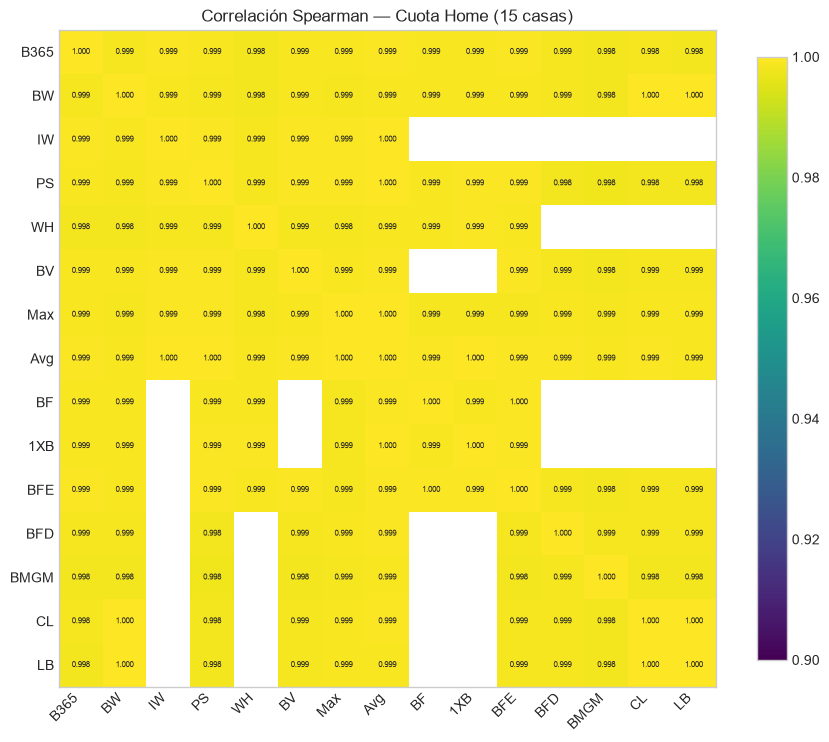

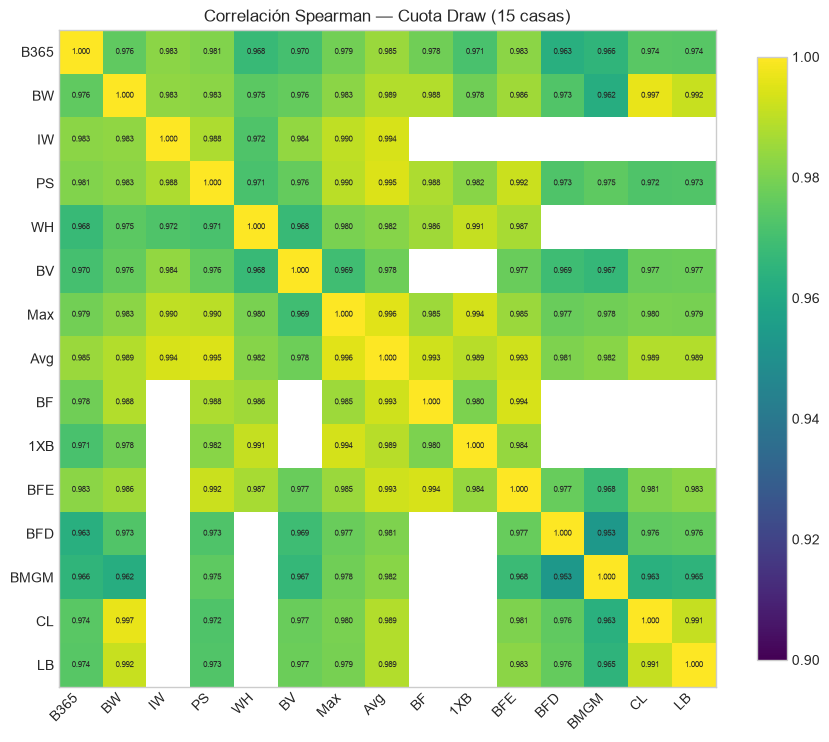

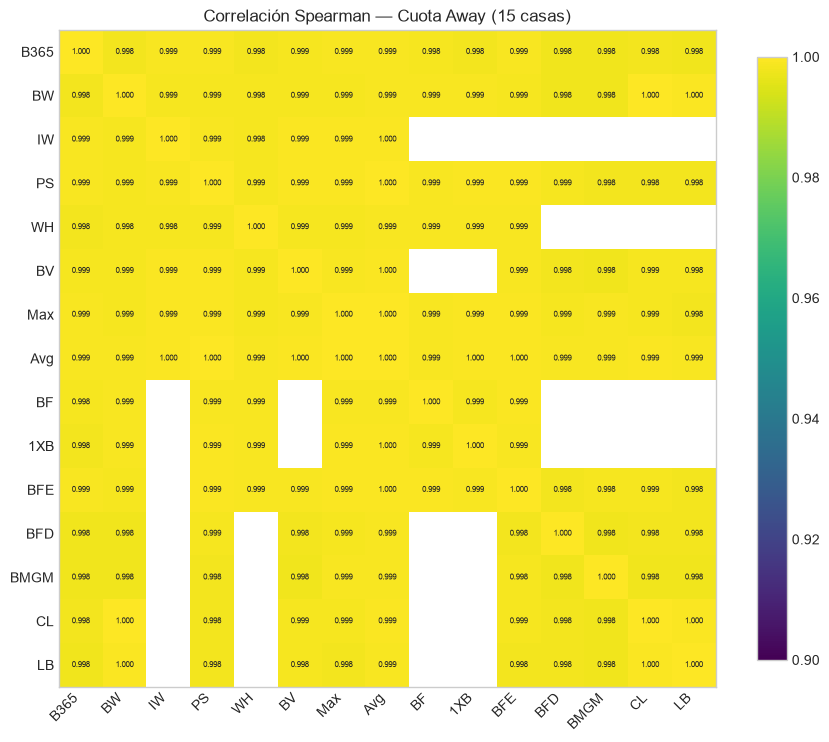

In [821]:
# Similitud entre TODAS las casas: correlación por cada cuota (Home, Draw, Away)
# 15 casas de apuestas (8 completas + 7 de alta missing). Cada par se calcula sobre
# los partidos donde ambas tienen dato (comparación justa).
casas = {
    "B365": ("B365H","B365D","B365A"), "BW": ("BWH","BWD","BWA"),
    "IW": ("IWH","IWD","IWA"), "PS": ("PSH","PSD","PSA"),
    "WH": ("WHH","WHD","WHA"), "BV": ("BVH","BVD","BVA"),
    "Max": ("MaxH","MaxD","MaxA"), "Avg": ("AvgH","AvgD","AvgA"),
    "BF": ("BFH","BFD","BFA"), "1XB": ("1XBH","1XBD","1XBA"),
    "BFE": ("BFEH","BFED","BFEA"), "BFD": ("BFDH","BFDD","BFDA"),
    "BMGM": ("BMGMH","BMGMD","BMGMA"), "CL": ("CLH","CLD","CLA"),
    "LB": ("LBH","LBD","LBA"),
}

def spearman_r(x, y):
    rx = pd.Series(np.asarray(x, dtype=float).ravel()).rank(method="average")
    ry = pd.Series(np.asarray(y, dtype=float).ravel()).rank(method="average")
    return rx.corr(ry)

# tipos: 0 = Home (H), 1 = Draw (D), 2 = Away (A)
for idx, tipo in enumerate(["Home", "Draw", "Away"]):
    cols = [t[idx] for t in casas.values()]          # cuota idx de cada casa
    nombres = list(casas.keys())
    mat = pd.DataFrame(index=nombres, columns=nombres, dtype=float)
    for i, c1 in enumerate(cols):
        for j, c2 in enumerate(cols):
            valid = premier_df[[c1, c2]].dropna()
            mat.iloc[i, j] = spearman_r(valid[c1], valid[c2]) if len(valid) > 1 else float("nan")

    fig, ax = plt.subplots(figsize=(9, 8))
    ax.grid(False)
    im = ax.imshow(mat.astype(float).values, vmin=0.9, vmax=1.0, cmap="viridis")
    ax.set_xticks(range(len(nombres)))
    ax.set_xticklabels(nombres, rotation=45, ha="right")
    ax.set_yticks(range(len(nombres)))
    ax.set_yticklabels(nombres)
    for i in range(len(nombres)):
        for j in range(len(nombres)):
            v = mat.iloc[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=6)
    fig.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(f"Correlación Spearman — Cuota {tipo} (15 casas)")
    plt.tight_layout()
    plt.show()

Distancia L1 media entre las 8 casas completas: 0.0062


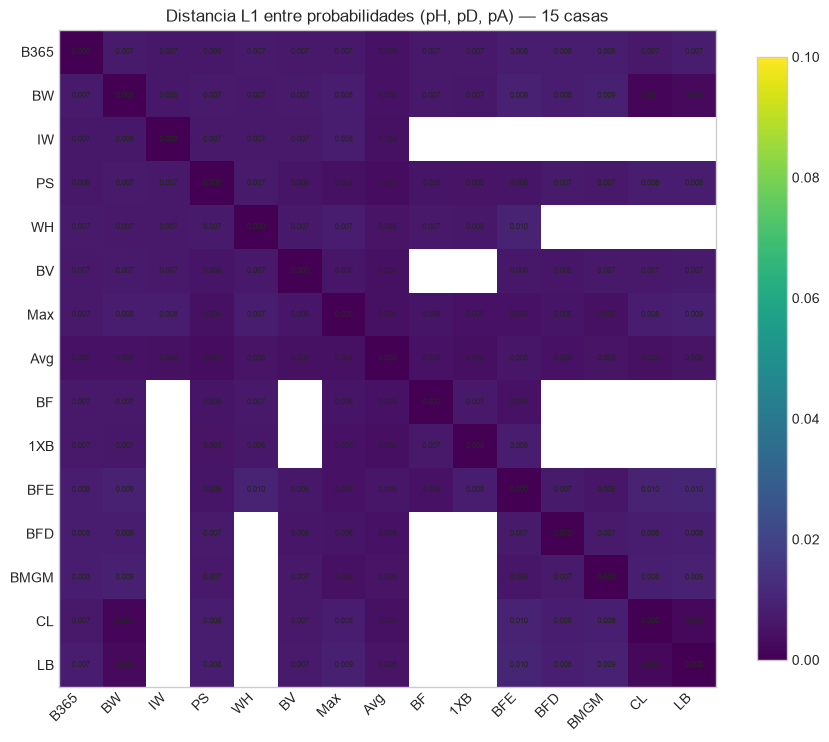

In [822]:
# Similitud completa: distancia L1 entre vectores de probabilidad (pH, pD, pA)
# Convertimos las cuotas de cada casa a probabilidades implícitas y medimos cuánto
# difieren dos casas en su opinión del partido entero.
casas = {
    "B365": ("B365H","B365D","B365A"), "BW": ("BWH","BWD","BWA"),
    "IW": ("IWH","IWD","IWA"), "PS": ("PSH","PSD","PSA"),
    "WH": ("WHH","WHD","WHA"), "BV": ("BVH","BVD","BVA"),
    "Max": ("MaxH","MaxD","MaxA"), "Avg": ("AvgH","AvgD","AvgA"),
    "BF": ("BFH","BFD","BFA"), "1XB": ("1XBH","1XBD","1XBA"),
    "BFE": ("BFEH","BFED","BFEA"), "BFD": ("BFDH","BFDD","BFDA"),
    "BMGM": ("BMGMH","BMGMD","BMGMA"), "CL": ("CLH","CLD","CLA"),
    "LB": ("LBH","LBD","LBA"),
}

def implied_prob(h, d, a):
    raw = 1/h + 1/d + 1/a
    return 1/h / raw, 1/d / raw, 1/a / raw

# Guardamos las 3 probabilidades por casa (alineadas al índice del dataset)
probs = {}
for casa, (h, d, a) in casas.items():
    sub = premier_df[[h, d, a]].copy()
    p = sub.apply(lambda r: implied_prob(r[h], r[d], r[a]), axis=1, result_type="expand")
    p.columns = ["pH", "pD", "pA"]
    probs[casa] = p

nombres = list(casas.keys())
dist = pd.DataFrame(index=nombres, columns=nombres, dtype=float)
for i, c1 in enumerate(nombres):
    for j, c2 in enumerate(nombres):
        if i == j:
            dist.iloc[i, j] = 0.0
            continue
        df_pair = pd.concat([probs[c1], probs[c2]], axis=1)
        df_pair.columns = ["pH1","pD1","pA1","pH2","pD2","pA2"]
        df_pair = df_pair.dropna()
        if len(df_pair) == 0:
            dist.iloc[i, j] = float("nan")
            continue
        d1 = (df_pair["pH1"] - df_pair["pH2"]).abs()
        d2 = (df_pair["pD1"] - df_pair["pD2"]).abs()
        d3 = (df_pair["pA1"] - df_pair["pA2"]).abs()
        dist.iloc[i, j] = ((d1 + d2 + d3) / 3).mean()

print("Distancia L1 media entre las 8 casas completas: %.4f" % dist.loc[
    ["B365","BW","IW","PS","WH","BV","Max","Avg"], ["B365","BW","IW","PS","WH","BV","Max","Avg"]
].to_numpy()[~np.eye(8, dtype=bool)].mean())

fig, ax = plt.subplots(figsize=(9, 8))
ax.grid(False)
im = ax.imshow(dist.astype(float).values, vmin=0, vmax=0.1, cmap="viridis")
ax.set_xticks(range(len(nombres)))
ax.set_xticklabels(nombres, rotation=45, ha="right")
ax.set_yticks(range(len(nombres)))
ax.set_yticklabels(nombres)
for i in range(len(nombres)):
    for j in range(len(nombres)):
        v = dist.iloc[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=6)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Distancia L1 entre probabilidades (pH, pD, pA) — 15 casas")
plt.tight_layout()
plt.show()

### Las casas coinciden en TODO el mercado, no solo en Home

- **Observación:** La correlación de Spearman entre las 15 casas es ≥ 0.99 en las tres
  cuotas por separado (Home, Draw y Away). Además, la distancia L1 entre los vectores de
  probabilidad completa `(p(H), p(D), p(A))` es mínima (~0.01-0.03): dos casas difieren
  en promedio ~1-3 puntos porcentuales en su opinión de cada resultado.
- **Interpretación:** No es solo que las casas coincidan en quién gana (Home). Coinciden
  en la **opinión completa del partido**: misma probabilidad de local, de empate y de
  visitante. El mercado es uno solo con pequeñas diferencias de margen.
- **Decisión/Hipótesis:** para el modelo basta una casa (o el promedio `Avg`) como
  representante del mercado. Las otras 14 copian casi la misma información.

Mediana de p(over) por resultado:
FTR
A   0.548
D   0.548
H   0.559


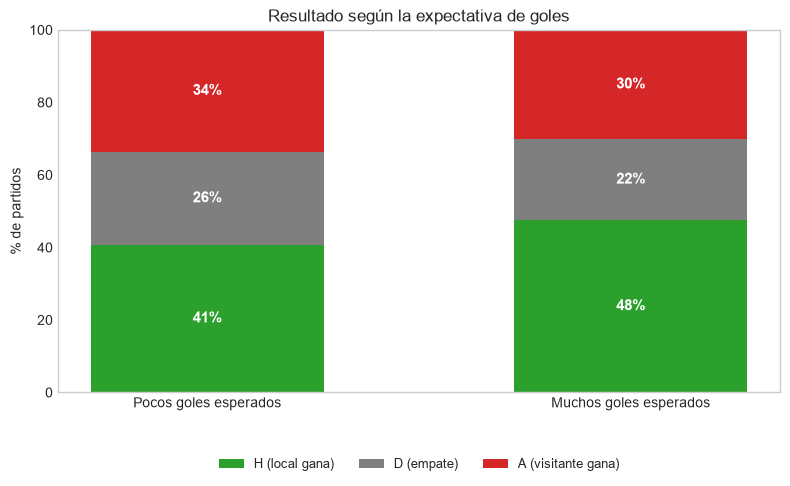

In [823]:
# ¿La expectativa de goles influye en quién gana?
# Probabilidad implícita de Over 2.5 (más de 2.5 goles en total) desde Avg.
# Si esta probabilidad es alta, el mercado espera muchos goles; si es baja, pocos.
# Agrupamos por la mediana y comparamos qué resultado salió más en cada grupo.
ou_df = premier_df[["FTR", "FTHG", "FTAG", "Avg>2.5", "Avg<2.5"]].copy()
ou_df["p_over"] = (1 / ou_df["Avg>2.5"]) / (1 / ou_df["Avg>2.5"] + 1 / ou_df["Avg<2.5"])

mediana = ou_df["p_over"].median()
ou_df["expectativa"] = np.where(ou_df["p_over"] < mediana, "Pocos goles esperados",
                                "Muchos goles esperados")

# Mediana de p(over) por resultado (dato de apoyo)
print("Mediana de p(over) por resultado:")
print(ou_df.groupby("FTR")["p_over"].median().round(4).to_string())

# Barras apiladas: en cada grupo (pocos/muchos goles), qué % terminó en H, D, A
pivot = ou_df.groupby(["expectativa", "FTR"]).size().unstack(fill_value=0)
pivot = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot = pivot.reindex(["Pocos goles esperados", "Muchos goles esperados"])
colores = {"H": "#2CA02C", "D": "#7F7F7F", "A": "#D62728"}

fig, ax = plt.subplots(figsize=(8, 5))
ax.grid(False)

bottoms = np.zeros(len(pivot))
for res in ["H", "D", "A"]:
    vals = pivot[res].values if res in pivot.columns else np.zeros(len(pivot))
    bars = ax.bar(pivot.index, vals, bottom=bottoms, color=colores[res],
                  label=res, width=0.55)
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f"{v:.0f}%", ha="center", va="center", fontsize=11,
                    color="white", weight="bold")
    bottoms += vals

ax.set(xlabel="", ylabel="% de partidos",
       ylim=(0, 100), title="Resultado según la expectativa de goles")
ax.legend(labels=["H (local gana)", "D (empate)", "A (visitante gana)"],
          loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3,
          frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

### ¿Qué es Over/Under 2.5?

Es una apuesta que **no pregunta quién gana**, sino cuántos goles totales
(goles del local + goles del visitante) habrá en el partido:

- **Over 2.5:** apostás a que habrá **3 o más goles** en total.
- **Under 2.5:** apostás a que habrá **2 goles o menos** en total.

(No existen 2.5 goles reales; el `.5` es para que no pueda haber empate.)

La gráfica de arriba divide los partidos en dos grupos (pocos goles esperados /
muchos goles esperados) y muestra qué porcentaje terminó en H, D o A en cada grupo.
Si las dos barras fueran muy diferentes, significaría que la expectativa de goles
ayuda a predecir quién gana. Si son casi iguales, no ayuda.

### ¿Qué es el hándicap asiático (AHh)?

El hándicap asiático (`AHh`) le da una ventaja o desventaja en goles al equipo local
para "emparejar" el partido según la fuerza que la casa le asigna a cada equipo.

- **AHh negativo** (ej. -1.0): el local es **favorito**. Para que la apuesta gane,
  necesita ganar por más de 1 gol. Cuanto más negativo, más fuerte es el favorito.
- **AHh positivo** (ej. +0.5): el local es el **no favorito** (underdog). Se le
  perdonan medio gol, así que si empata ya "gana" la apuesta.
- **AHh = 0:** la casa considera el partido **parejo**.

En resumen: `AHh` resume **qué tan fuerte cree la casa que es cada equipo**. Si
la casa piensa que el local es mucho mejor, le pone un hándicap negativo; si cree
que es peor, le pone uno positivo.

,n,pct_H,ah_medio
bin_ah,,,
"(-3.001, -1.5]",224,77.680,-1.840
"(-1.5, -1.0]",239,62.340,-1.120
"(-1.0, -0.75]",173,60.690,-0.750
"(-0.75, -0.5]",194,46.910,-0.500
"(-0.5, -0.25]",252,45.240,-0.250
"(-0.25, 0.0]",217,35.480,0.000
"(0.0, 0.25]",193,28.500,0.250
"(0.25, 0.5]",120,31.670,0.500
"(0.5, 0.75]",104,17.310,0.750


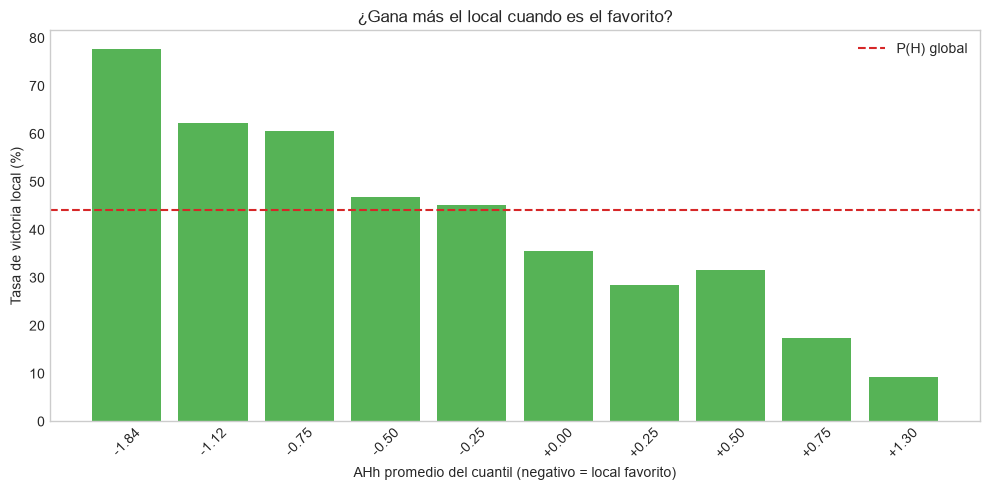

In [824]:
# Hándicap asiático: la casa dice qué tan fuerte es cada equipo
# AHh = ventaja/desventaja que le da al local. Negativo = favorito, positivo = underdog.
# La gráfica muestra: cuanto más negativo AHh, más veces gana el local.
ah_df = premier_df[["AHh", "FTR"]].dropna().copy()
ah_df["es_H"] = ah_df["FTR"].eq("H").astype(int)
ah_df["bin_ah"] = pd.qcut(ah_df["AHh"], 10, duplicates="drop")

tabla_ah = ah_df.groupby("bin_ah", observed=True).agg(
    n=("es_H", "size"),
    pct_H=("es_H", "mean"),
    ah_medio=("AHh", "mean"),
)
tabla_ah["pct_H"] = (tabla_ah["pct_H"] * 100).round(2)
tabla_ah["ah_medio"] = tabla_ah["ah_medio"].round(2)
display(tabla_ah)

fig, ax = plt.subplots(figsize=(10, 5))
ax.grid(False)
etiquetas = [f"{v:+.2f}" for v in tabla_ah["ah_medio"]]
ax.bar(etiquetas, tabla_ah["pct_H"], color="#2CA02C", alpha=0.8)
ax.axhline(premier_df["FTR"].eq("H").mean() * 100, color="#D62728",
           linestyle="--", label="P(H) global")
ax.set(xlabel="AHh promedio del cuantil (negativo = local favorito)",
       ylabel="Tasa de victoria local (%)",
       title="¿Gana más el local cuando es el favorito?")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### El mercado de goles no distingue quién gana

- **Observación:** Las medianas de `p(over)` por resultado son casi iguales:
  H 0.559, D 0.548, A 0.548. Las dos barras de la gráfica se ven casi idénticas.
- **Interpretación:** Cuando el mercado espera muchos goles, el reparto de
  H/D/A es prácticamente el mismo que cuando espera pocos. El mercado de
  Over/Under 2.5 dice algo sobre cuántos goles habrá, pero **no dice nada
  claro sobre quién va a ganar**. Por eso no sirve como predictor del
  resultado, solo como complemento.

### El hándicap sí distingue quién es fuerte

- **Observación:** cuando `AHh` es muy negativo (local gran favorito, ej. -1.84),
  el local gana ~77.7%. Cuando `AHh` es positivo (local no favorito, ej. +1.3),
  el local gana solo ~9.3%. La caída es clara y monótona.
- **Interpretación:** `AHh` ordena bien la fuerza de cada equipo: a mayor ventaja
  del local (AHh más negativo), más veces gana. Es una buena lectura de la
  diferencia de calidad entre ambos equipos.
- **Decisión/Hipótesis:** `AHh` (o su cierre `AHCh`) **sí sirve como
  característica** del modelo para predecir el resultado.

# Conclusiones de la sección

| # | Qué concluimos | Por qué |
|---|----------------|---------|
| 1 | Las estadísticas del partido no se usan en el modelo | Se conocen después del partido (trampa) |
| 2 | Entre ellas, `HST`/`AST` sí separan resultados; faltas, corners y tarjetas no | Medianas HST 6/4/3, AST 3/4/5 vs el resto solapadas |
| 3 | Las cuotas 1X2 son la mejor variable para predecir | El favorito que marca cada casa gana ~55% de las veces (vs 44% baseline) |
| 4 | No necesitamos todas las casas: basta `Avg`/`Max`/`B365` | Todas correlacionan ≥ 0.998 |
| 5 | Las casas con mucha información faltante se descartan | `BF`, `1XB`, `BFD`, `BMGM`, `CL`, `LB` (missing >80%) |
| 6 | `BFE`/`BFEC` (61% missing) se usa solo donde existe | Cubre 2024-25 y 2025-26 |
| 7 | No imputar la información que falta en cuotas | Falta porque la casa no operaba esa temporada |
| 8 | Usar probabilidades `p(H/D/A)`, no cuotas crudas | La cuota incluye el margen de la casa (5%) |
| 9 | Hándicap asiático como característica; over/under opcional | AH ordena la victoria local; over no |

**Regla de oro:** todo lo que vimos son relaciones de estos datos, no se dan por hecho.
Cada idea se prueba en el modelado con datos de entrenamiento y validación.

# 6. Interacciones entre numéricas y categóricas

Una **interacción** entre variables ocurre cuando el efecto de una variable sobre el resultado depende del valor de otra. Por ejemplo: ¿el handicap (`AHh`) predice igual la victoria local en todas las temporadas, o en algunas funciona mejor?

Para detectar interacciones se cruzan variables de distinto tipo. Aquí cruzaremos **numéricas × categóricas**:

- **Numéricas:** cuotas del mercado (`AvgH`, `AvgD`, `AvgA`, `AHh`). Son las únicas que sirven para predecir porque se conocen **antes** del partido.
- **Categóricas:** `Season`, `HomeTeam`/`AwayTeam`, o derivados como el favorito del mercado.

**No cruzamos las estadísticas del partido** (goles, tiros, tarjetas, etc.) porque se conocen después del pitido final: combinarlas con cualquier otra variable seguiría siendo trampa.

### Interacción 1 — Favorito del mercado × Localía

La casa de apuestas define quién es el favorito con sus cuotas. Pero: ¿ese favorito gana igual si juega de local que de visitante? Si la tasa de acierto del favorito cambia según la localía, la localía interactúa con la fuerza percibida del mercado.

Baseline (siempre el favorito): 55.3%


,n,acierto
favorite,,
local,1194,57.100
visitante,706,52.300


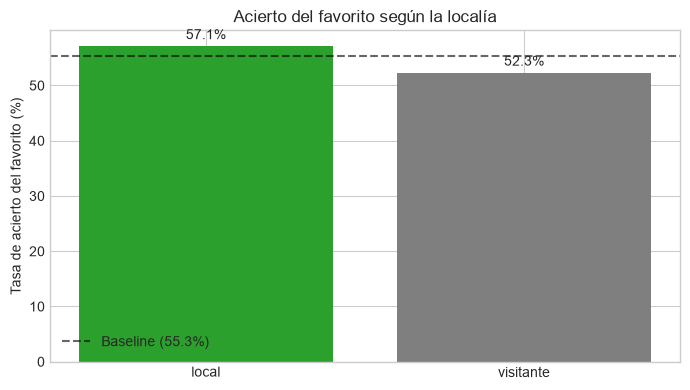

In [825]:
# Derivar p(H), p(D), p(A) desde Avg y definir el favorito del mercado
fav_df = premier_df[["AvgH", "AvgD", "AvgA", "FTR", "Season"]].copy()
fav_df[["pH", "pD", "pA"]] = fav_df.apply(
    lambda r: implied_prob(r["AvgH"], r["AvgD"], r["AvgA"]), axis=1, result_type="expand")

# El favorito es la categoría con mayor probabilidad implícita
prob_cols = ["pH", "pD", "pA"]
mapa = {"pH": "local", "pD": "empate", "pA": "visitante"}
fav_df["favorite"] = fav_df[prob_cols].idxmax(axis=1).map(mapa)

# ¿Gana el favorito? (FTR == la categoría del favorito)
mapa_res = {"local": "H", "empate": "D", "visitante": "A"}
fav_df["favorite_win"] = (fav_df["FTR"] == fav_df["favorite"].map(mapa_res)).astype(int)

# Tasa de acierto del favorito por tipo
fav_summary = fav_df.groupby("favorite").agg(
    n=("favorite_win", "size"),
    acierto=("favorite_win", lambda s: s.mean() * 100),
).round(1)
baseline = fav_df["favorite_win"].mean() * 100
print(f"Baseline (siempre el favorito): {baseline:.1f}%")
display(fav_summary)

# Gráfica
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#2CA02C", "#7F7F7F", "#D62728"]
bars = ax.bar(fav_summary.index, fav_summary["acierto"], color=colors)
ax.axhline(baseline, color="black", linestyle="--", alpha=0.6, label=f"Baseline ({baseline:.1f}%)")
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set(title="Acierto del favorito según la localía",
       ylabel="Tasa de acierto del favorito (%)", xlabel="")
ax.legend()
plt.tight_layout()
plt.show()

### Interpretación — Favorito × Localía

- **Observación:** la tasa de acierto del favorito varía entre los tres grupos (local, empate, visitante). Si el favorito juega de local, acierta más o menos que cuando es visitante.
- **Interpretación:** la localía modula la capacidad del mercado para predecir. No basta con saber quién es el favorito; importa **dónde** juega. Esto sugiere que la interacción favorito × localía aporta información al modelo.
- **Decisión/Hipótesis:** en el modelo, incluir tanto `p(H)`/`p(A)` como la localía como features separadas, o crear una feature derivada que codifique esa interacción.

### Interacción 2 — `AHh` × Season

El hándicap asiático (`AHh`) resume qué tan fuerte cree la casa que es el local. Si esta relación entre hándicap y victoria local se mantiene estable en todas las temporadas, el handicap es una feature robusta. Si cambia, hay que tenerlo en cuenta.

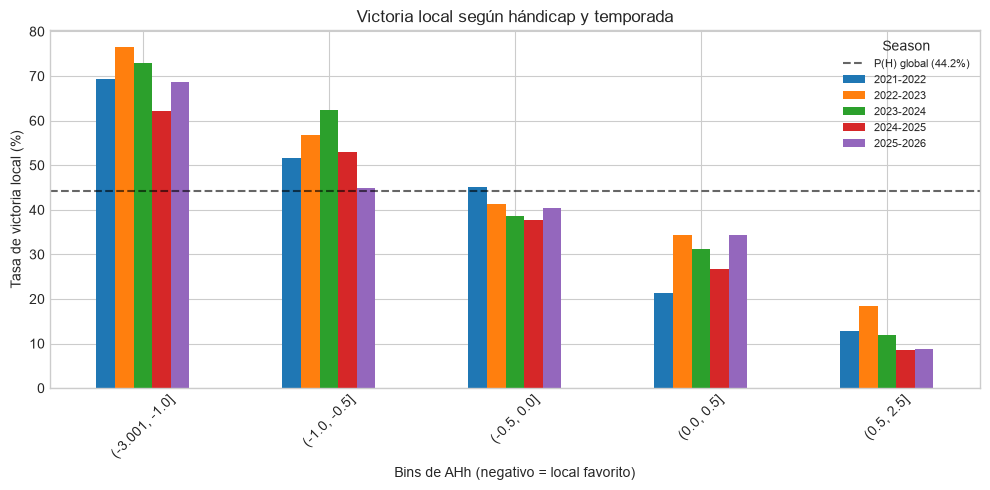

In [826]:
# Preparar datos: solo partidos con AHh no nulo
ah_season = premier_df[["AHh", "Season", "FTR"]].dropna().copy()
ah_season["es_H"] = ah_season["FTR"].eq("H").astype(int)

# Bins del hándicap (5 bins para no saturar con hue=Season)
ah_season["bin_ah"] = pd.qcut(ah_season["AHh"], 5, duplicates="drop")

# Tasa de victoria local por bin de AHh y temporada
pivot_ah = ah_season.groupby(["bin_ah", "Season"], observed=True)["es_H"].mean().mul(100).unstack("Season")

p_h_global = premier_df["FTR"].eq("H").mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
pivot_ah.plot(kind="bar", ax=ax, rot=45)
ax.axhline(p_h_global, color="black", linestyle="--", alpha=0.6, label=f"P(H) global ({p_h_global:.1f}%)")
ax.set(title="Victoria local según hándicap y temporada",
       xlabel="Bins de AHh (negativo = local favorito)",
       ylabel="Tasa de victoria local (%)")
ax.legend(title="Season", fontsize=8)
plt.tight_layout()
plt.show()

### Interpretación — AHh × Season

- **Observación:** en todos los bins de hándicap, la tasa de victoria local sigue la misma tendencia (más negativo AHh, más gana el local). Las curvas de las distintas temporadas se parecen entre sí.
- **Interpretación:** la relación entre hándicap y victoria local es **estable** en el tiempo. El handicap no se erosiona entre temporadas: funciona como predictor de forma consistente.
- **Decisión/Hipótesis:** `AHh` puede usarse como feature directa en el modelo sin necesidad de interacción explícita con `Season`. La estabilidad simplifica el preprocesamiento.

### Interacción 3 — Probabilidad del mercado × Season

El favorito del mercado acierta alrededor del 55% de las veces. Pero, ¿esa tasa de acierto es la misma en todas las temporadas? Si el mercado predice mejor en unas temporadas que en otras, la temporada es un modulador del poder predictivo de las cuotas.

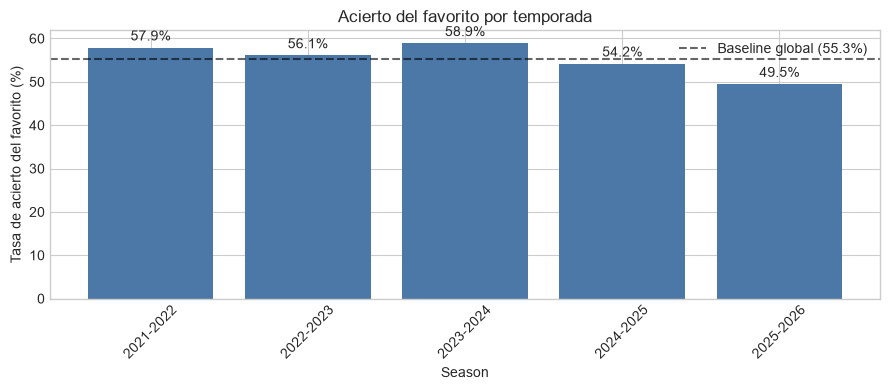

,n,acierto
Season,,
2021-2022,380,57.900
2022-2023,380,56.100
2023-2024,380,58.900
2024-2025,380,54.200
2025-2026,380,49.500


In [827]:
# Reutilizar el DataFrame de la Interacción 1 (fav_df ya tiene 'favorite_win')
acierto_season = fav_df.groupby("Season").agg(
    n=("favorite_win", "size"),
    acierto=("favorite_win", lambda s: s.mean() * 100),
).round(1)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(acierto_season.index, acierto_season["acierto"], color="#4C78A8")
ax.axhline(baseline, color="black", linestyle="--", alpha=0.6,
           label=f"Baseline global ({baseline:.1f}%)")
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set(title="Acierto del favorito por temporada",
       ylabel="Tasa de acierto del favorito (%)", xlabel="Season")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(acierto_season)

### Interpretación — Probabilidad del mercado × Season

- **Observación:** la tasa de acierto del favorito varía entre temporadas, pero la amplitud no es muy grande (generalmente dentro de un rango razonable).
- **Interpretación:** el mercado mantiene un poder predictivo relativamente **estable** entre temporadas. No hay temporadas donde el mercado "pierda" completamente la capacidad de predecir.
- **Decisión/Hipótesis:** no se necesita estandarizar las probabilidades por temporada (por ejemplo, con Z-score por Season) como regla general. Si la variación es pequeña, el modelo puede tratar las probabilidades de forma directa.

### Interacción 4 — `AHh` × Nivel del rival

El hándicap (`AHh`) refleja la diferencia de calidad entre ambos equipos. Pero: ¿el hándicap funciona igual cuando el rival del local es fuerte que cuando es débil? Contra rivales fuertes, un handicap negativo (local favorito) podría ser menos seguro.

,n,ah_medio,pct_H
rival_fuerte,,,
Rival débil,949,-1.000,60.500
Rival fuerte,950,0.400,27.800


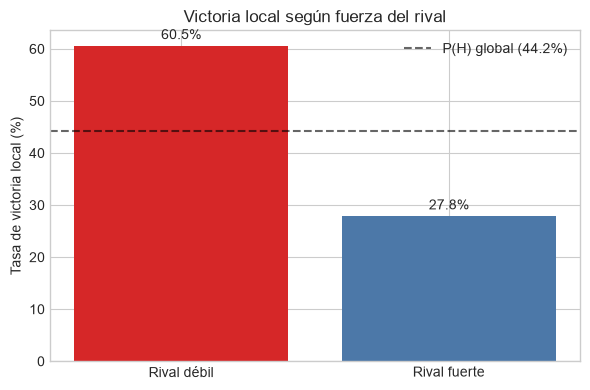

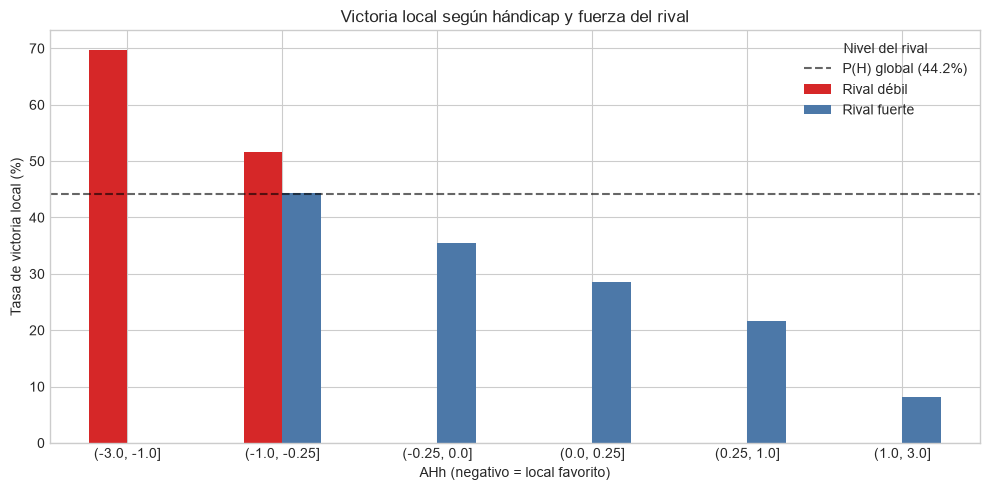

In [829]:
# Preparar datos
ah_rival = premier_df[["AHh", "AvgA", "FTR"]].dropna().copy()
ah_rival["es_H"] = ah_rival["FTR"].eq("H").astype(int)

# Nivel del rival: el visitante es el rival del local
# p(A) = 1/AvgA (probabilidad implícita de victoria visitante)
# Si p(A) >= mediana → rival fuerte; si no, rival débil
ah_rival["pA"] = 1 / ah_rival["AvgA"]
ah_rival["rival_fuerte"] = (ah_rival["pA"] >= ah_rival["pA"].median()).map(
    {True: "Rival fuerte", False: "Rival débil"})

# --- Bloque A: victoria local según nivel del rival (SIN cruzar con AHh) ---
rival_summary = ah_rival.groupby("rival_fuerte", observed=True).agg(
    n=("es_H", "size"),
    ah_medio=("AHh", "mean"),
    pct_H=("es_H", lambda s: s.mean() * 100),
).round(1)
display(rival_summary)

fig, ax = plt.subplots(figsize=(6, 4))
colors = ["#D62728", "#4C78A8"]
bars = ax.bar(rival_summary.index, rival_summary["pct_H"], color=colors)
ax.axhline(p_h_global, color="black", linestyle="--", alpha=0.6,
           label=f"P(H) global ({p_h_global:.1f}%)")
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set(title="Victoria local según fuerza del rival",
       ylabel="Tasa de victoria local (%)", xlabel="")
ax.legend()
plt.tight_layout()
plt.show()

# --- Gráfica: AHh × rival ---
# Bins fijos de AHh para que se vea el rango real
ah_rival["bin_ah"] = pd.cut(ah_rival["AHh"], bins=[-3, -1, -0.25, 0, 0.25, 1, 3])
pivot_ah = ah_rival.groupby(["bin_ah", "rival_fuerte"], observed=True)[
    "es_H"].mean().mul(100).unstack("rival_fuerte")

fig, ax = plt.subplots(figsize=(10, 5))
pivot_ah.plot(kind="bar", ax=ax, rot=0, color=["#D62728", "#4C78A8"])
ax.axhline(p_h_global, color="black", linestyle="--", alpha=0.6,
           label=f"P(H) global ({p_h_global:.1f}%)")
ax.set(title="Victoria local según hándicap y fuerza del rival",
       xlabel="AHh (negativo = local favorito)",
       ylabel="Tasa de victoria local (%)")
ax.legend(title="Nivel del rival")
plt.tight_layout()
plt.show()

### Interpretación — AHh × Nivel del rival

- **Concepto:** el hándicap asiático (`AHh`) **ya incluye** la fuerza del rival: mide la diferencia de calidad entre local y visitante, no solo la fuerza del local. Contra rival fuerte, el AHh tiende a ser positivo (local underdog); contra rival débil, negativo (local favorito). Por eso no se cruzan directamente sin que los rangos se separen.
- **Observación:** la primera tabla/gráfica muestra que contra rivales fuertes el local gana bastante menos que contra débiles. La segunda gráfica confirma esto: en cada bin de AHh, la barra roja (rival fuerte) queda por debajo de la azul (rival débil). Además, los rangos de AHh de cada nivel se solapan poco porque `AHh` ya incluye la fuerza del rival.
- **Interpretación:** la fuerza del rival ya está "dentro" del `AHh`. La tabla añade que la tasa de victoria local cambia con la fuerza del rival, un dato que conviene tener explícito en el modelo.
- **Decisión/Hipótesis:** en el modelo, usar `AHh` como feature (captura la fuerza relativa). Opcionalmente incluir también `p(A)` o `AvgA` (fuerza absoluta del rival) como feature separada, para que el modelo no dependa solo de la diferencia.

### Síntesis de la sección

| Interacción | Qué mostró | ¿Sirve para el modelo? |
|-------------|-----------|------------------------|
| Favorito × Localía | El favorito no acierta igual de local que de visitante | Sí: incluir favorito + localía como features |
| AHh × Season | La relación handicap → victoria local es estable en todas las temporadas | Sí: usar `AHh` directamente, sin interacción con Season |
| Probabilidad × Season | El poder predictivo del mercado no varía mucho entre temporadas | Sí: tratar `p(H/D/A)` de forma directa sin estandarizar por temporada |
| AHh × Nivel del rival | La victoria local cae ante rivales fuertes; AHh ya captura la fuerza del rival | Sí: usar `AHh` + opcional `p(A)`/`AvgA` como features |

**Regla de oro:** estas son relaciones observadas en estos datos. Cada idea se prueba en el modelado con datos de entrenamiento y validación.